## Run predictors


Transformation Pipeline and Model Successfully Loaded


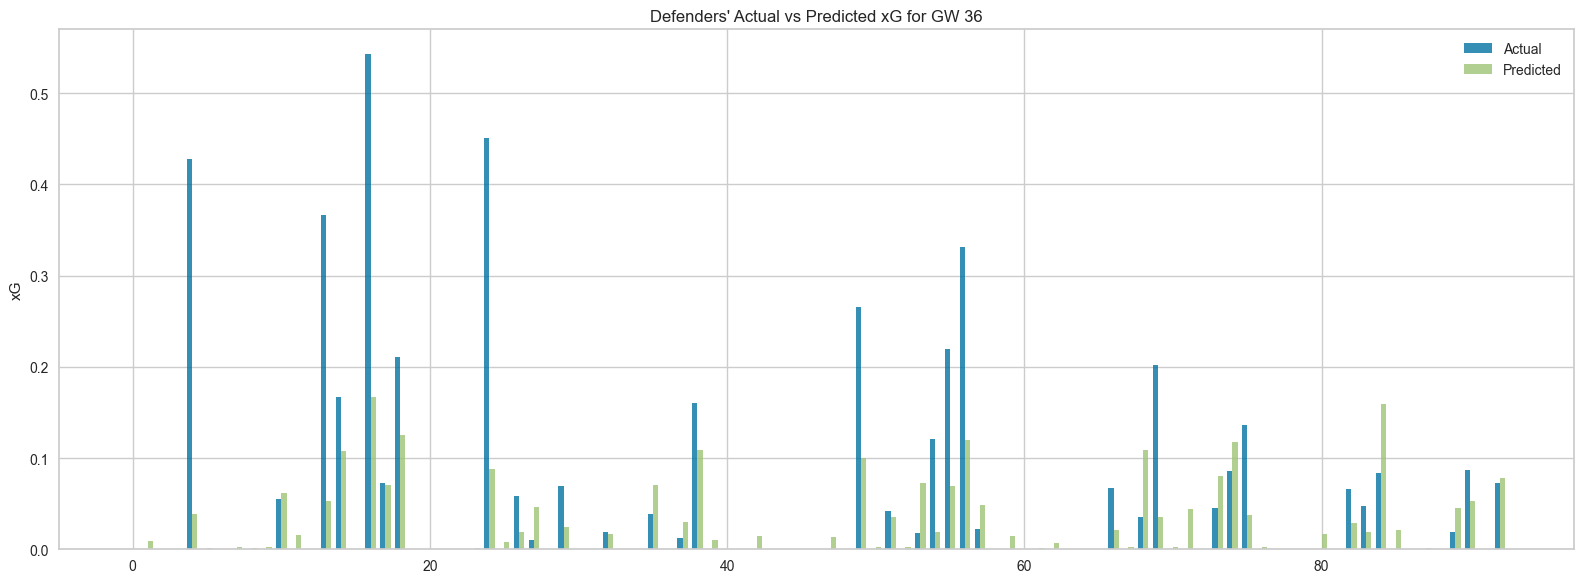

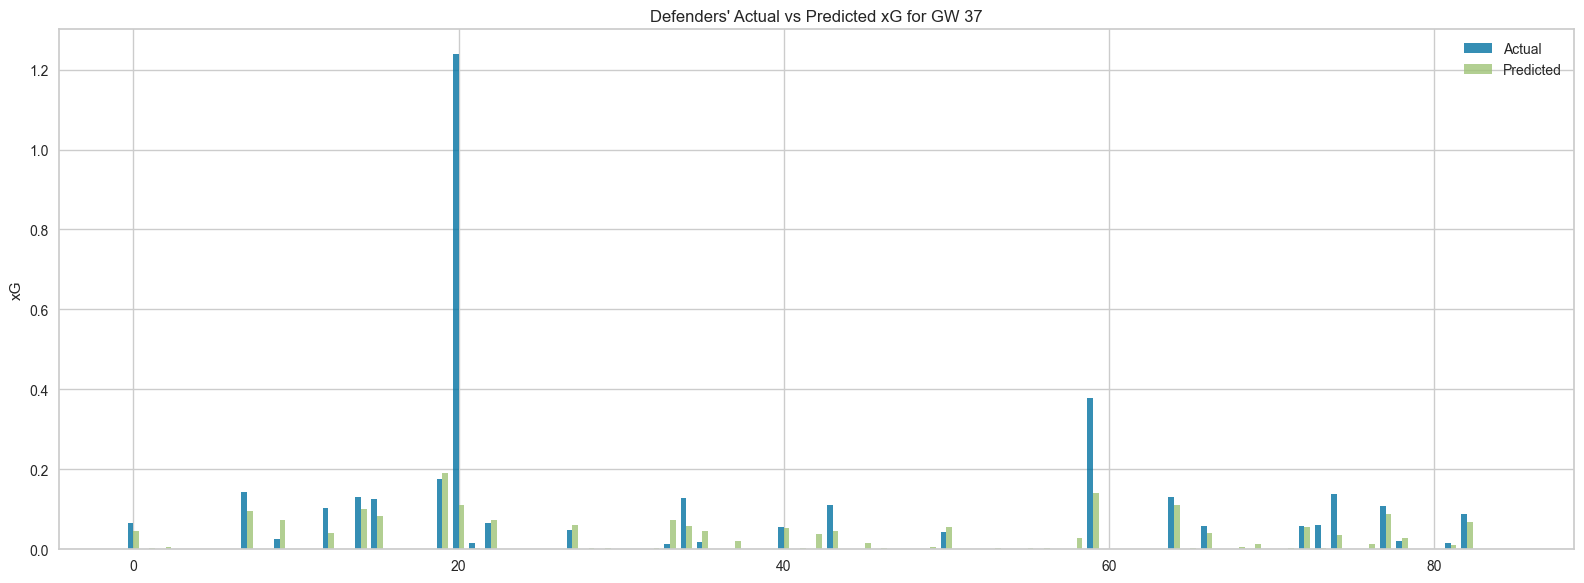

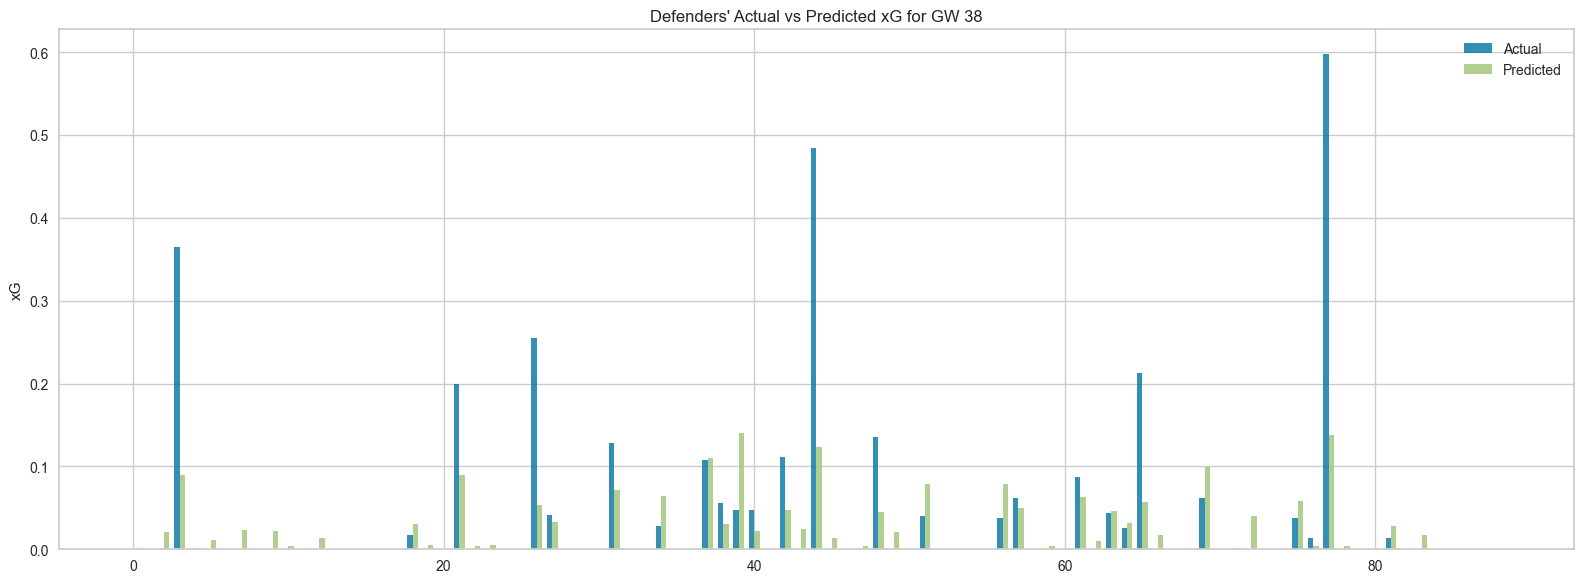

Transformation Pipeline and Model Successfully Loaded


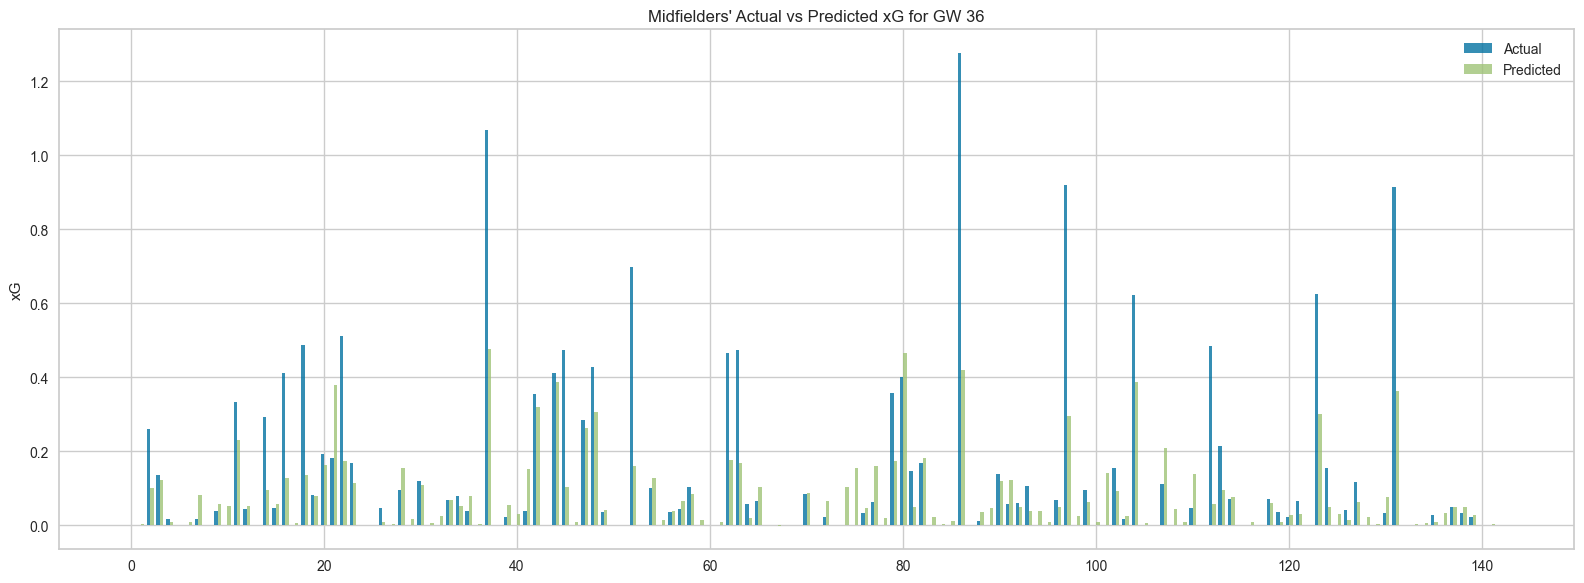

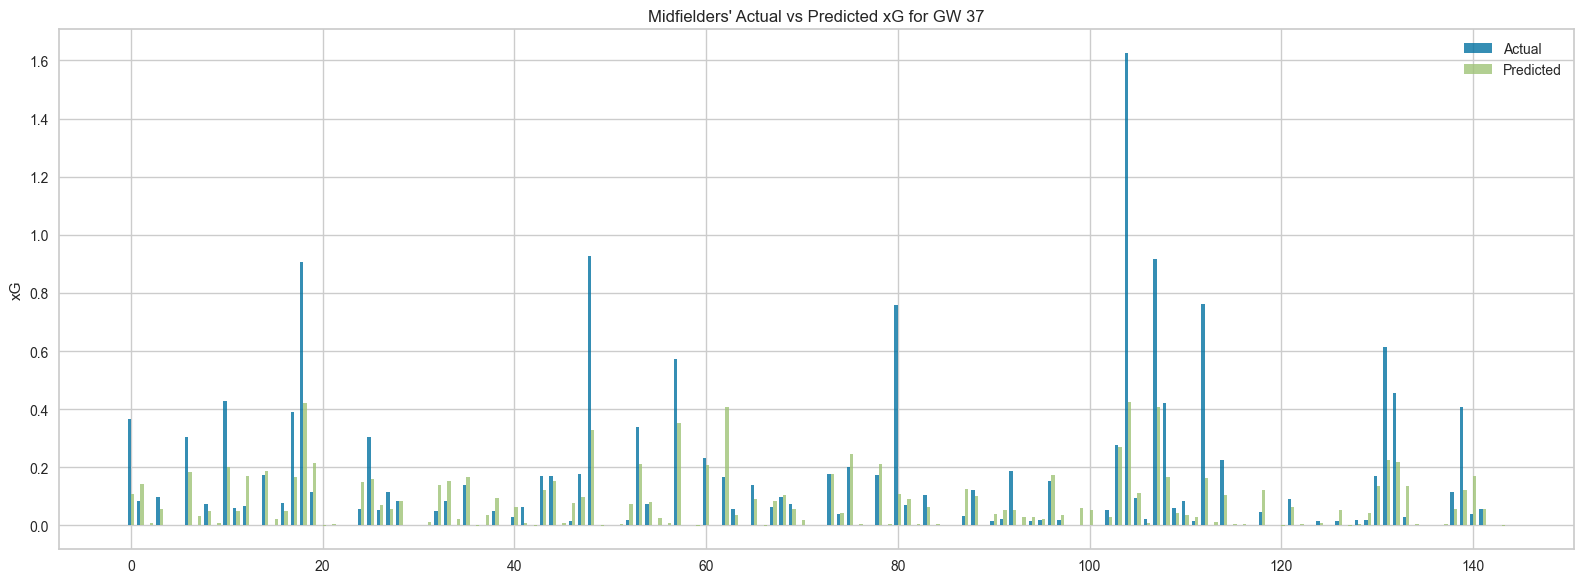

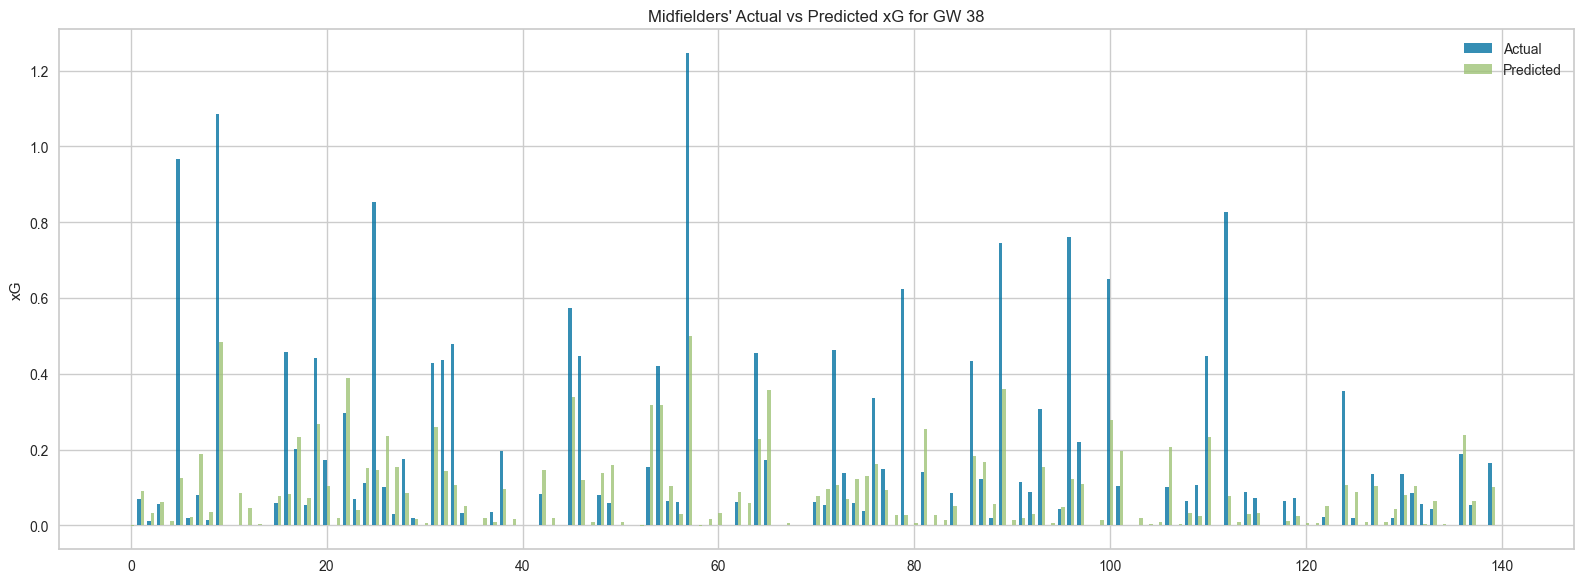

Transformation Pipeline and Model Successfully Loaded


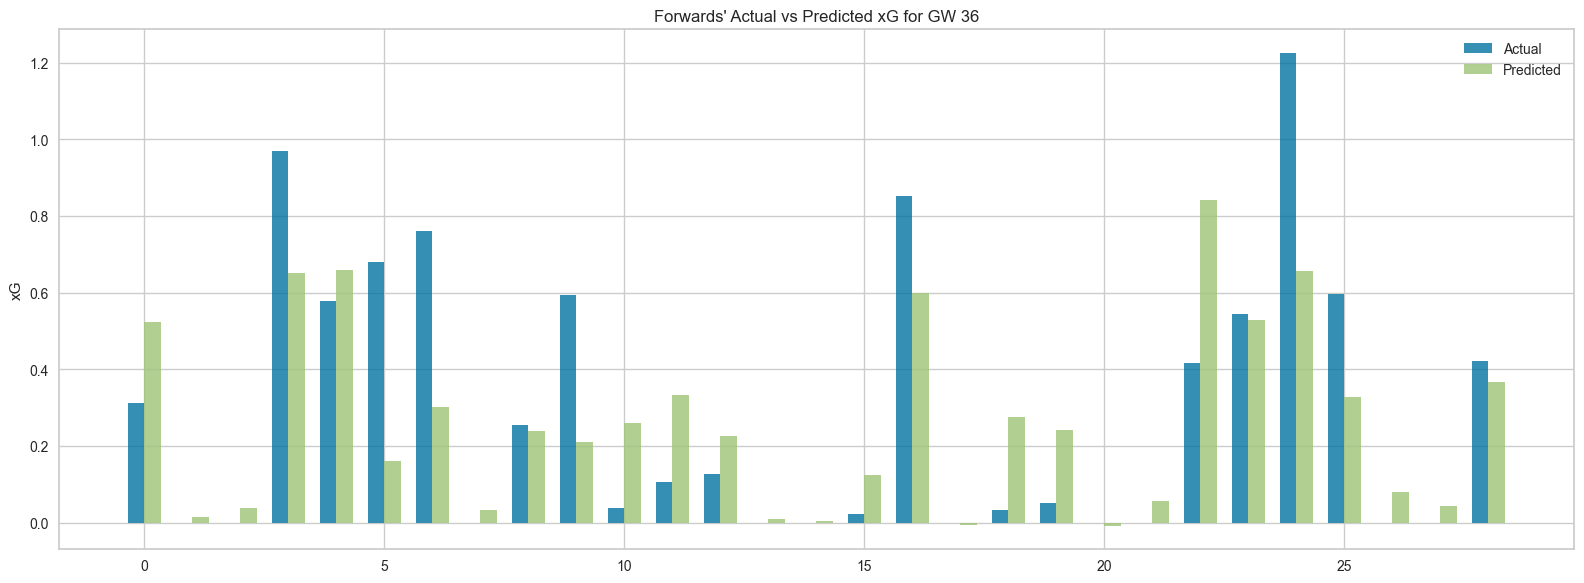

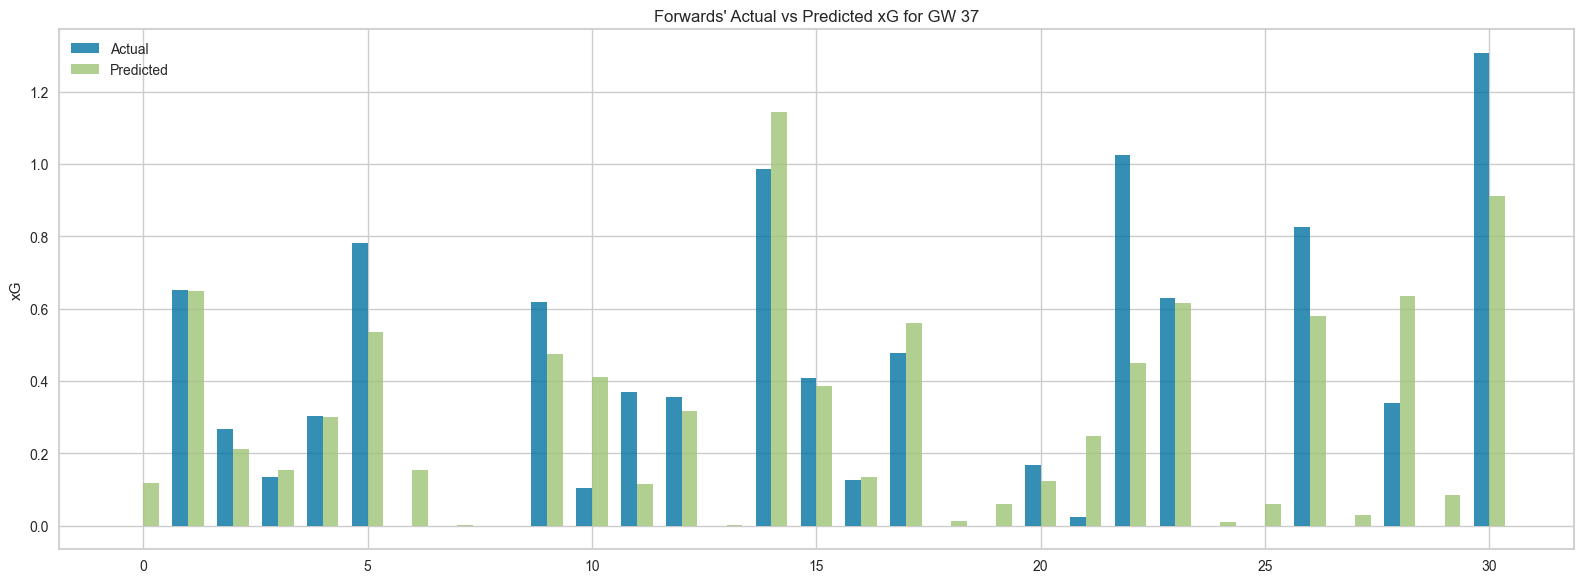

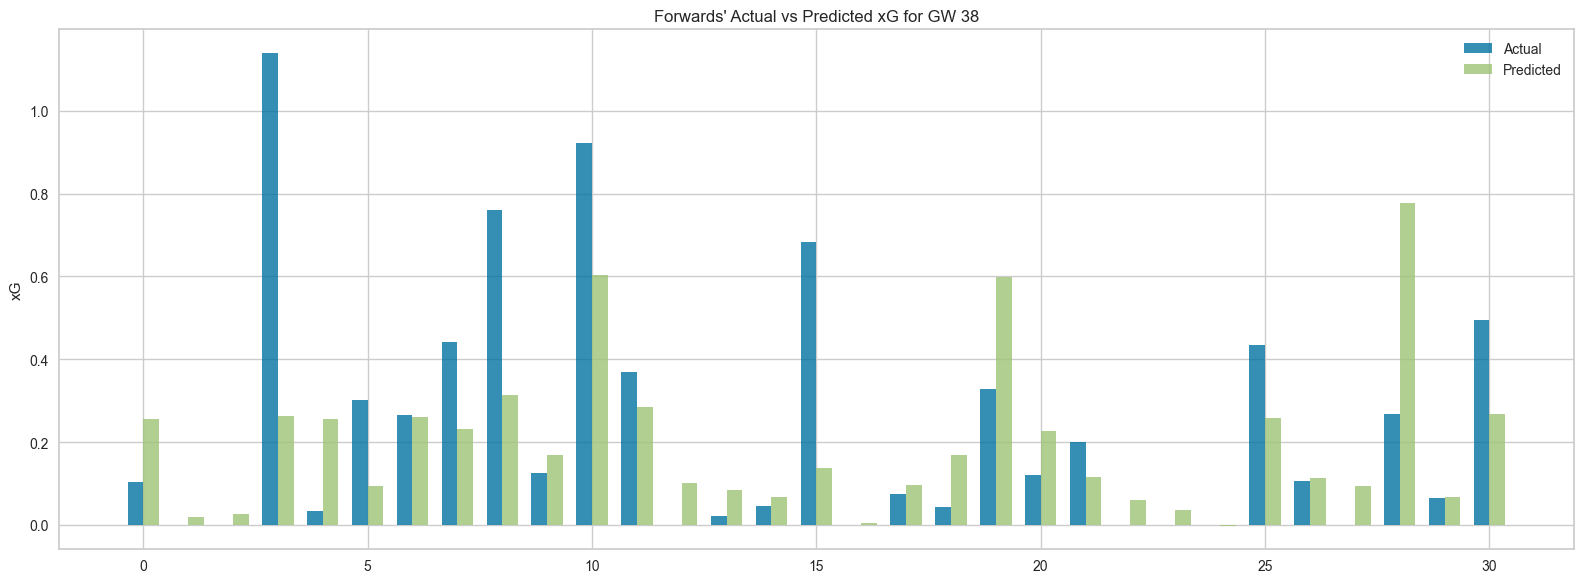

Transformation Pipeline and Model Successfully Loaded


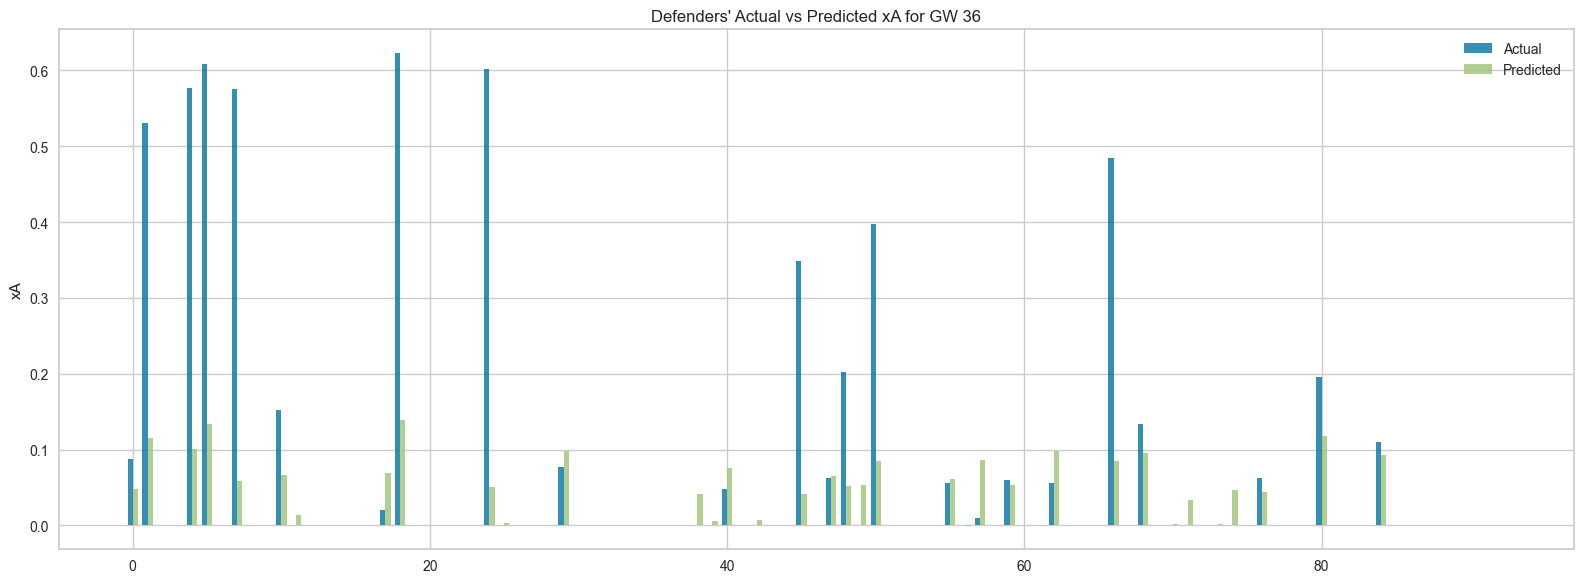

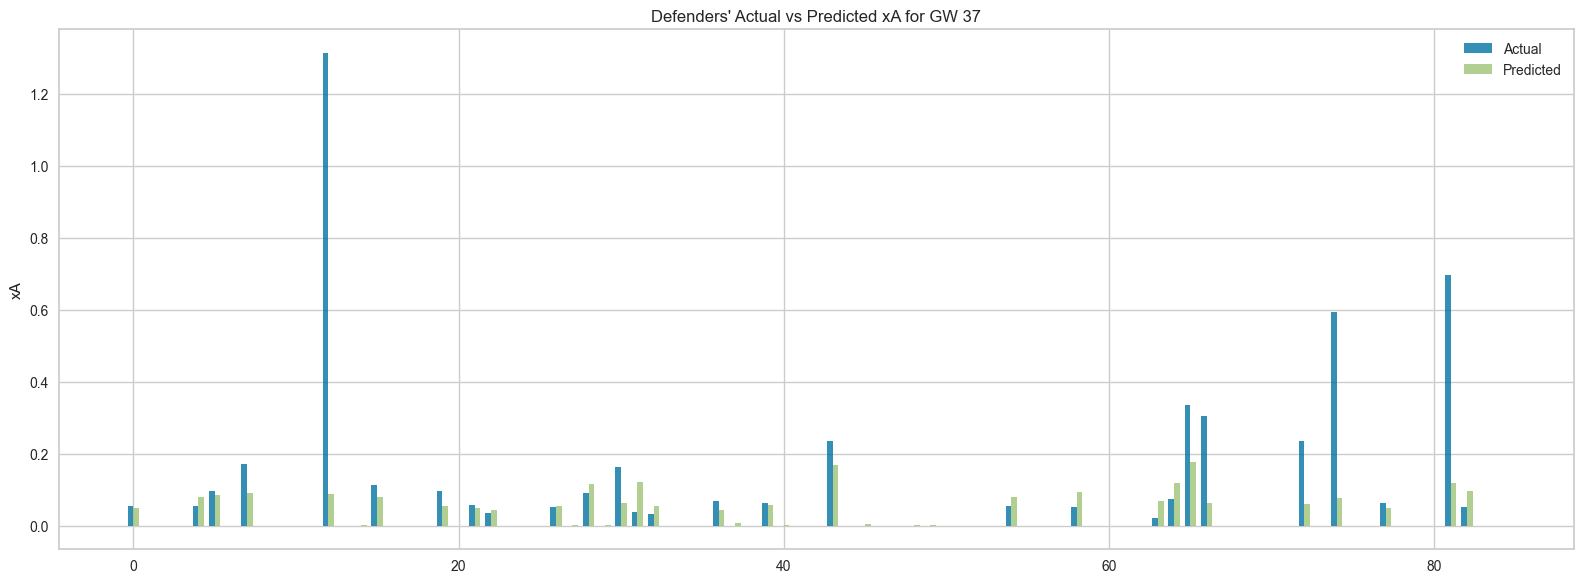

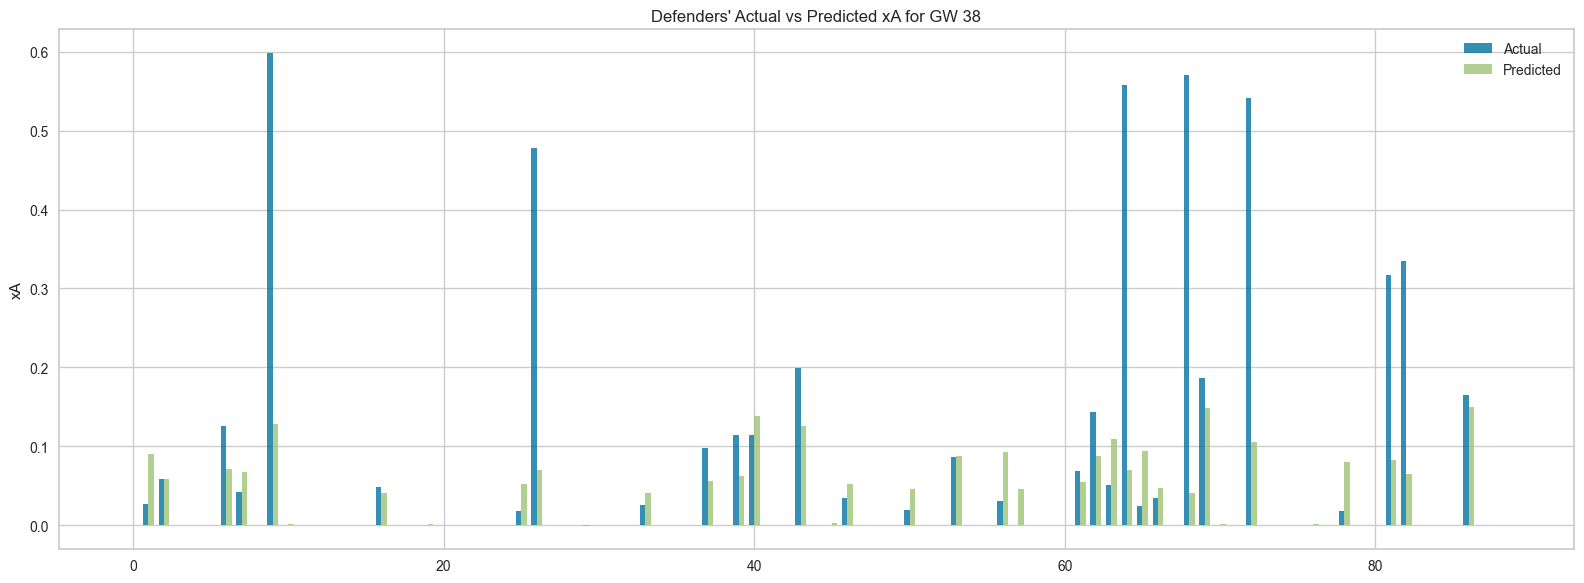

Transformation Pipeline and Model Successfully Loaded


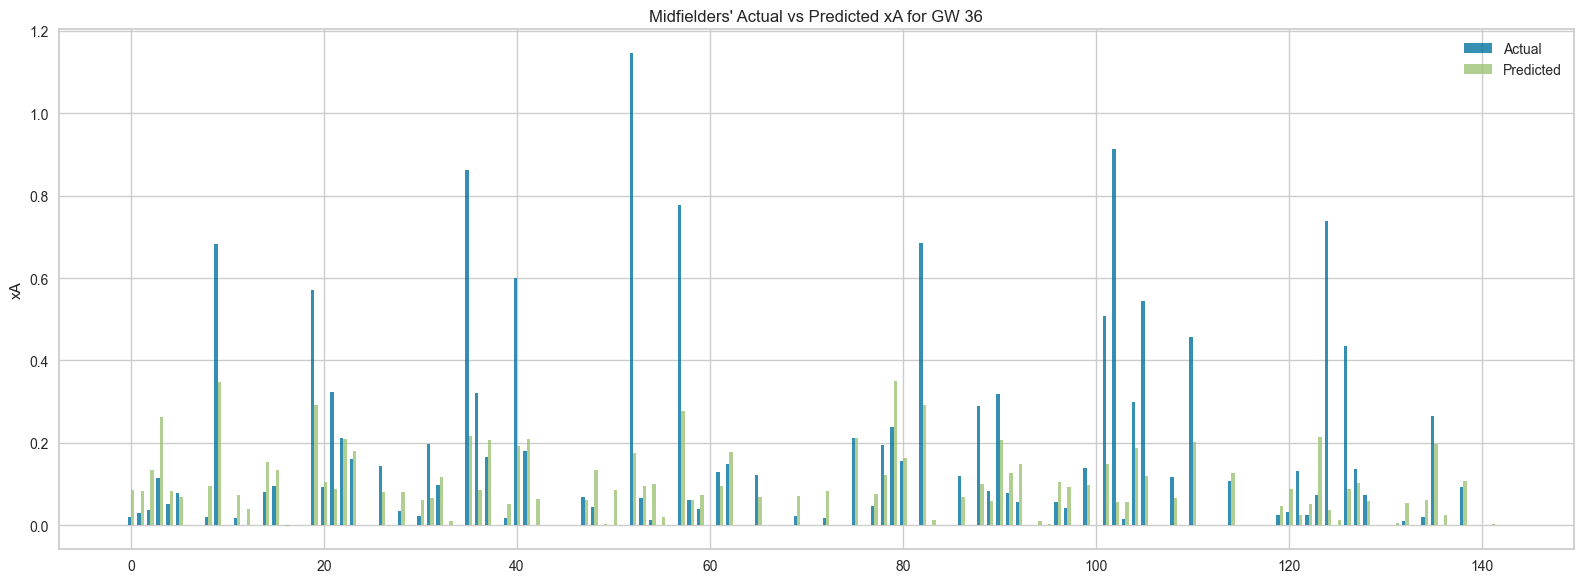

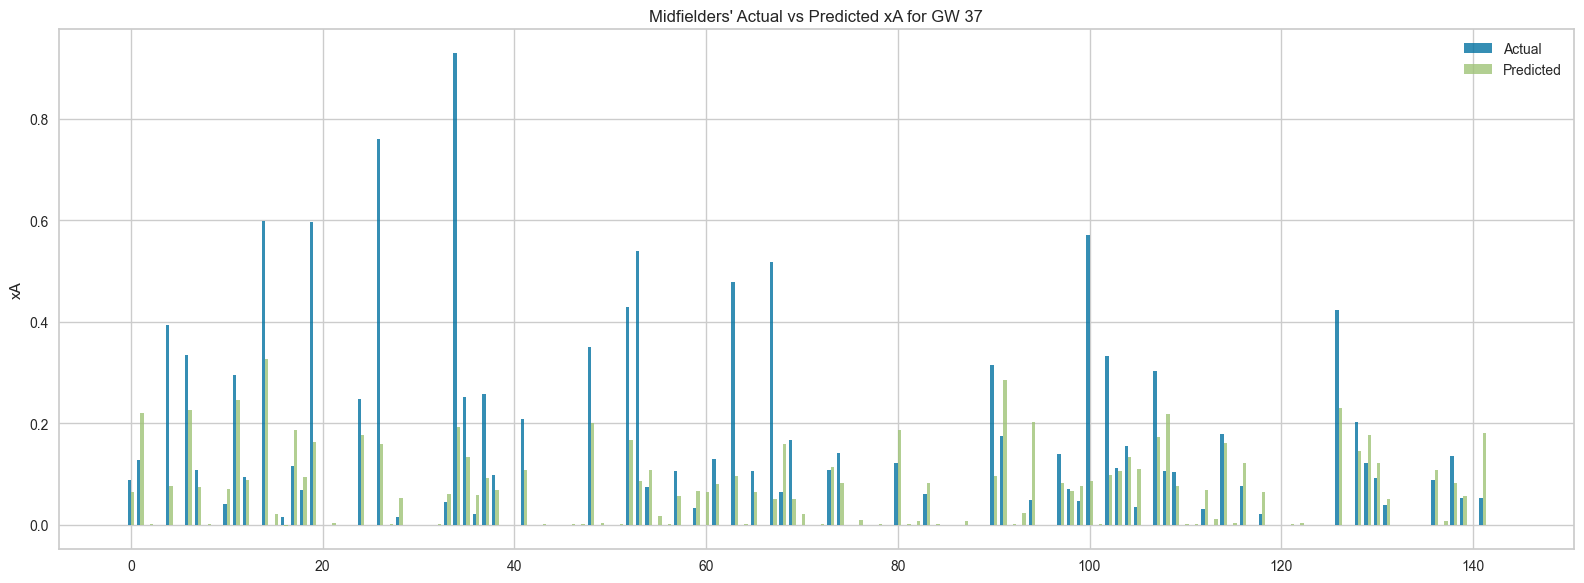

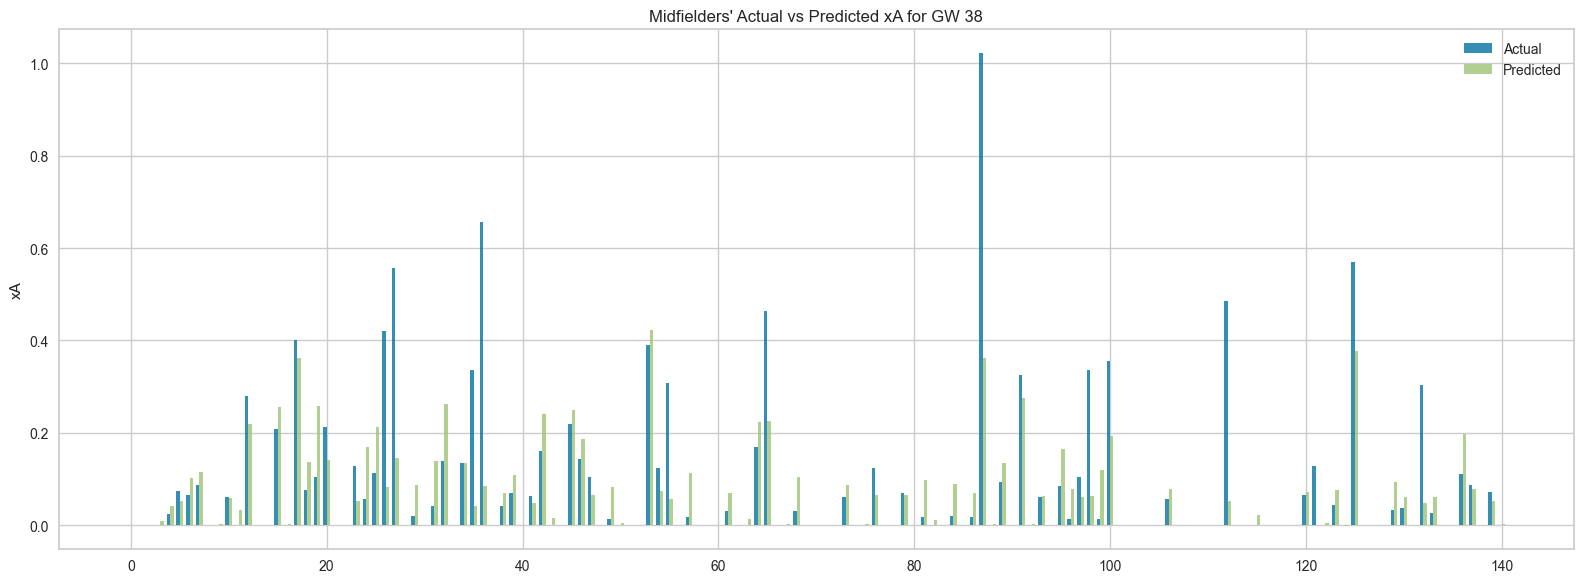

Transformation Pipeline and Model Successfully Loaded


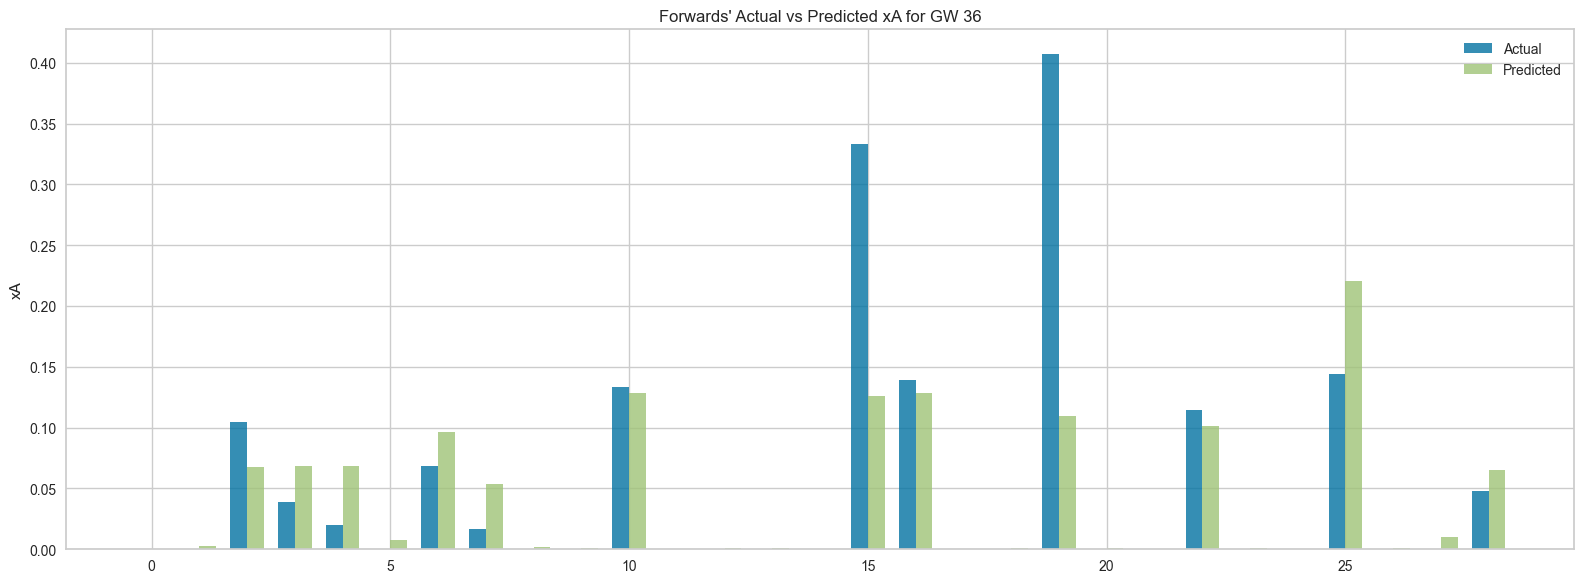

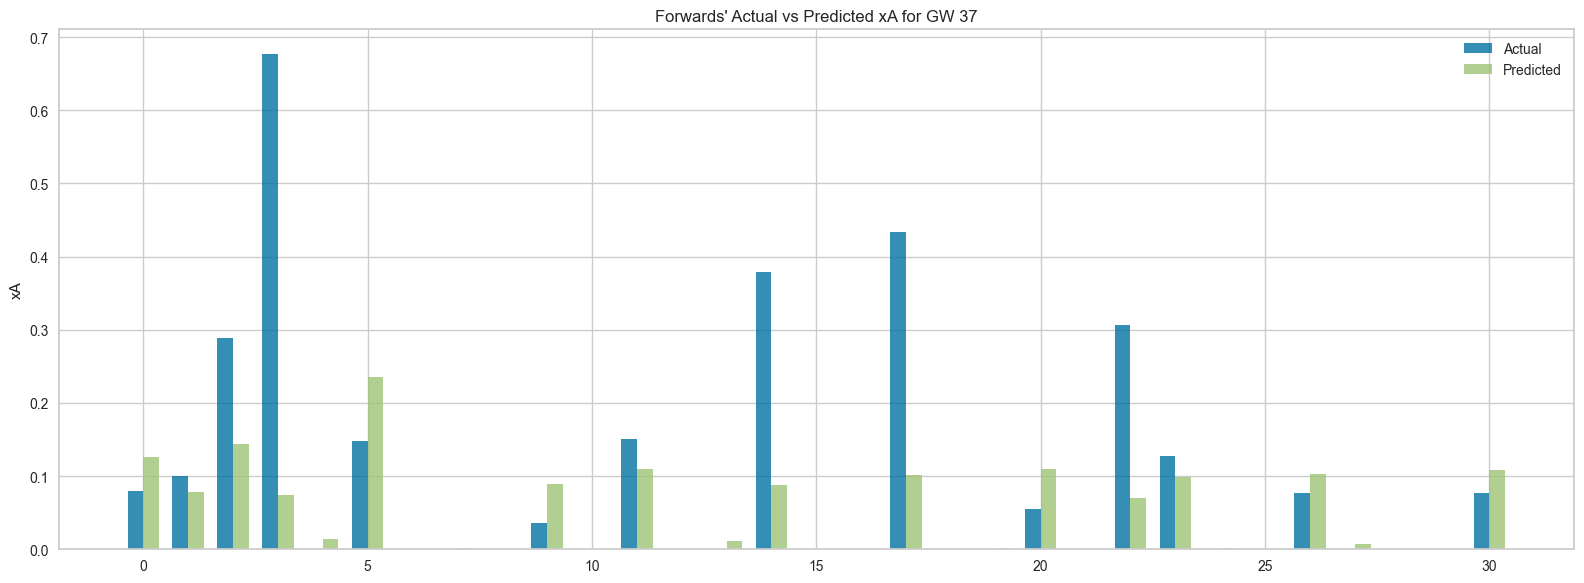

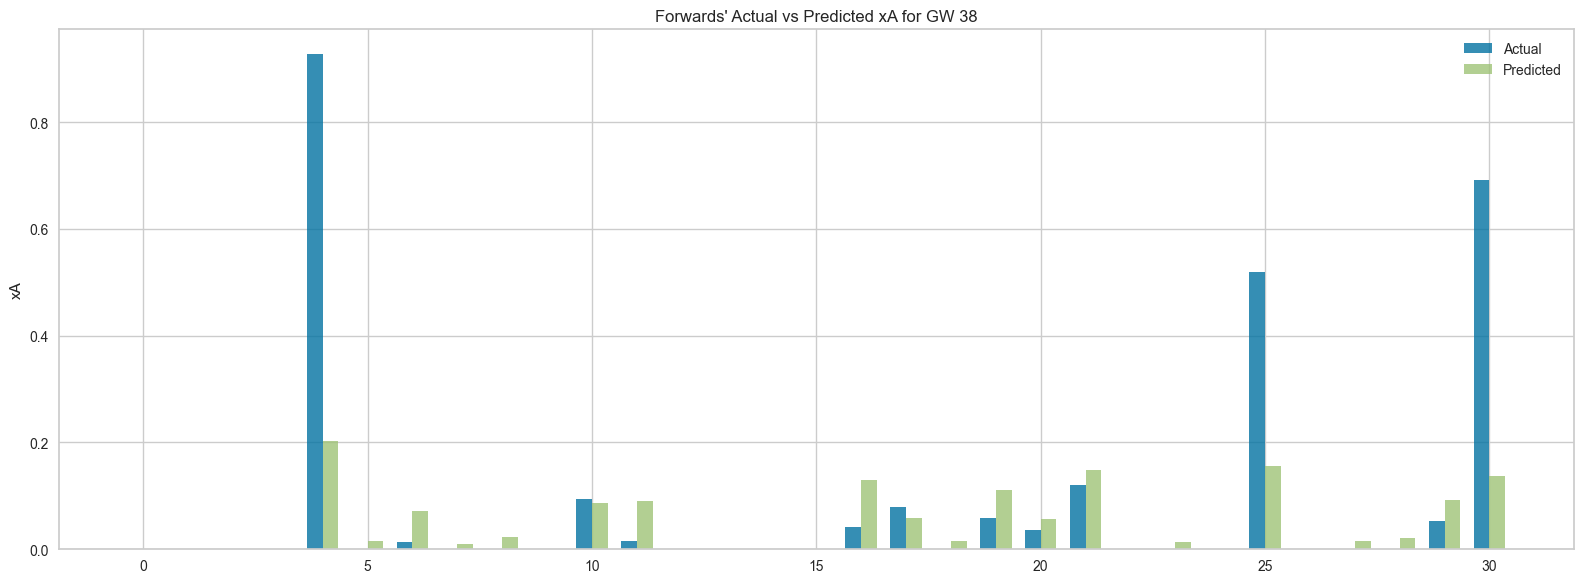

Transformation Pipeline and Model Successfully Loaded


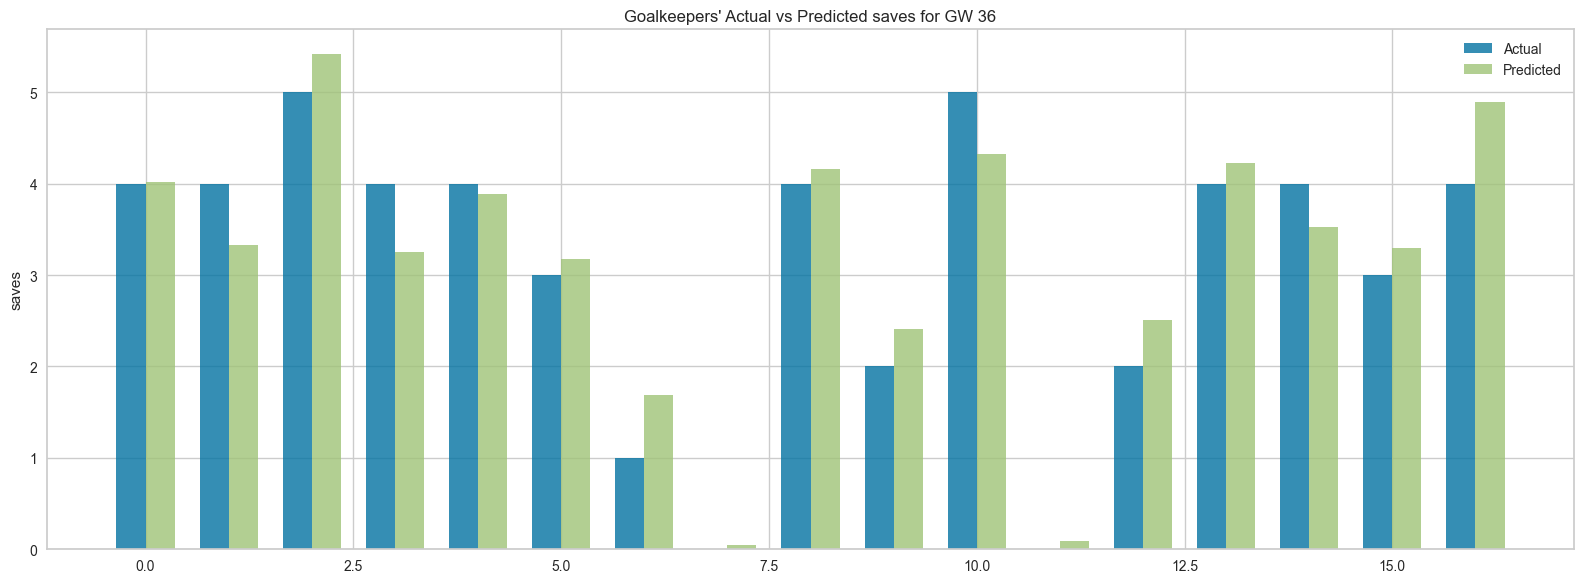

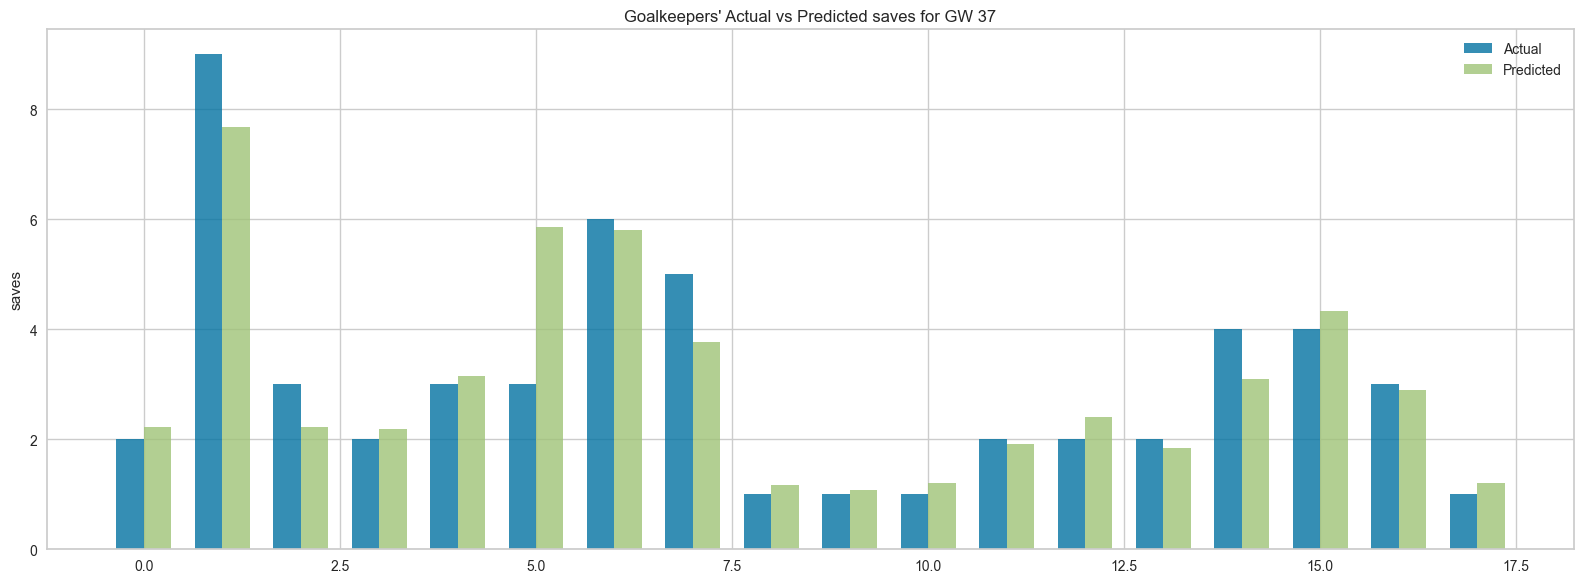

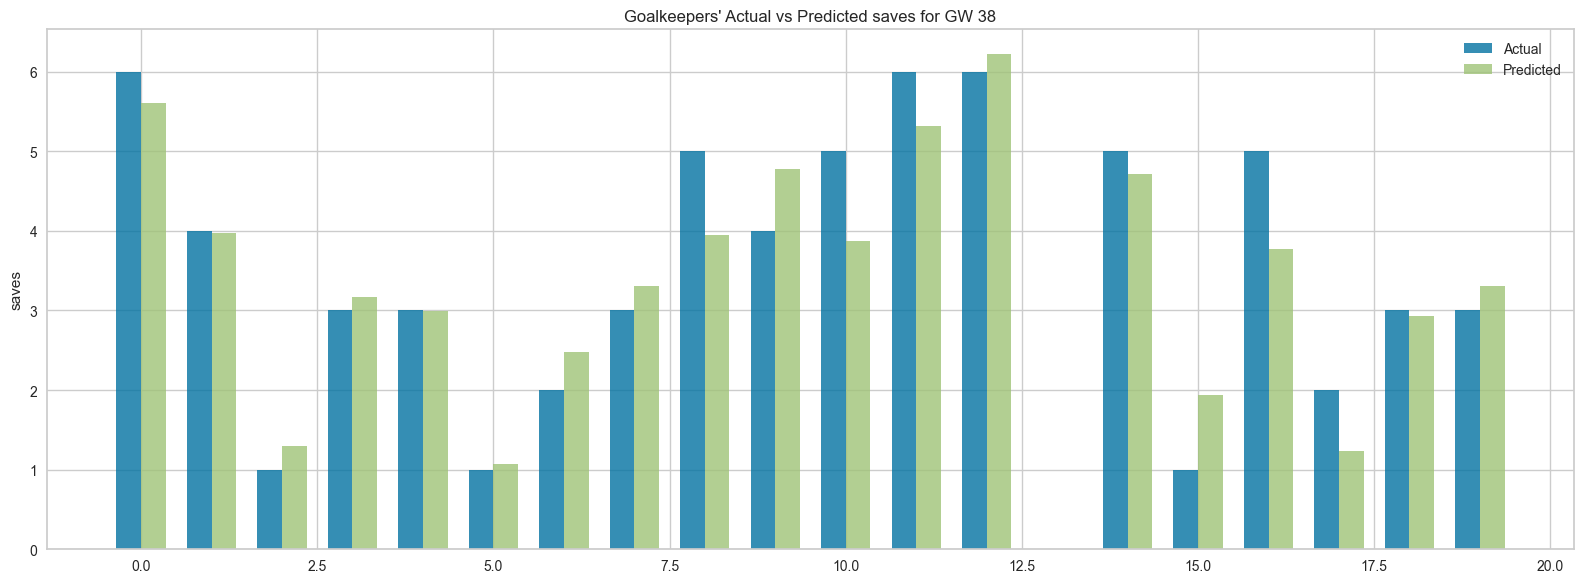

Transformation Pipeline and Model Successfully Loaded


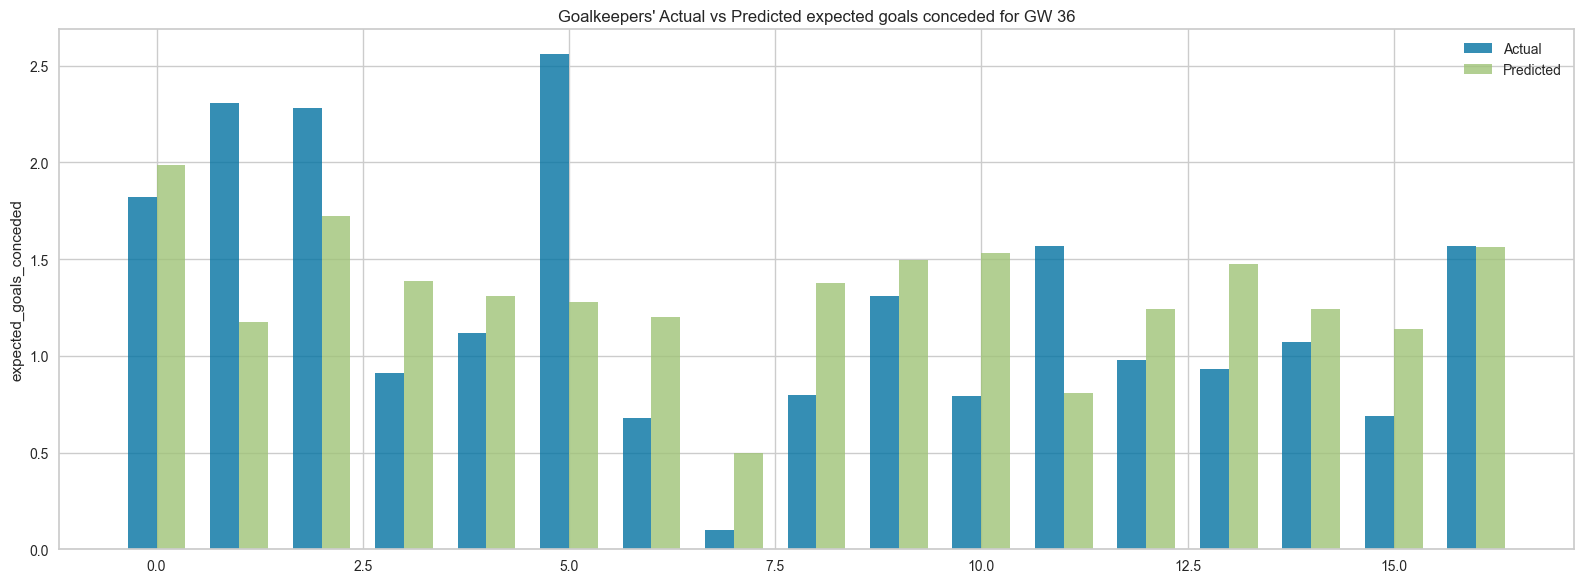

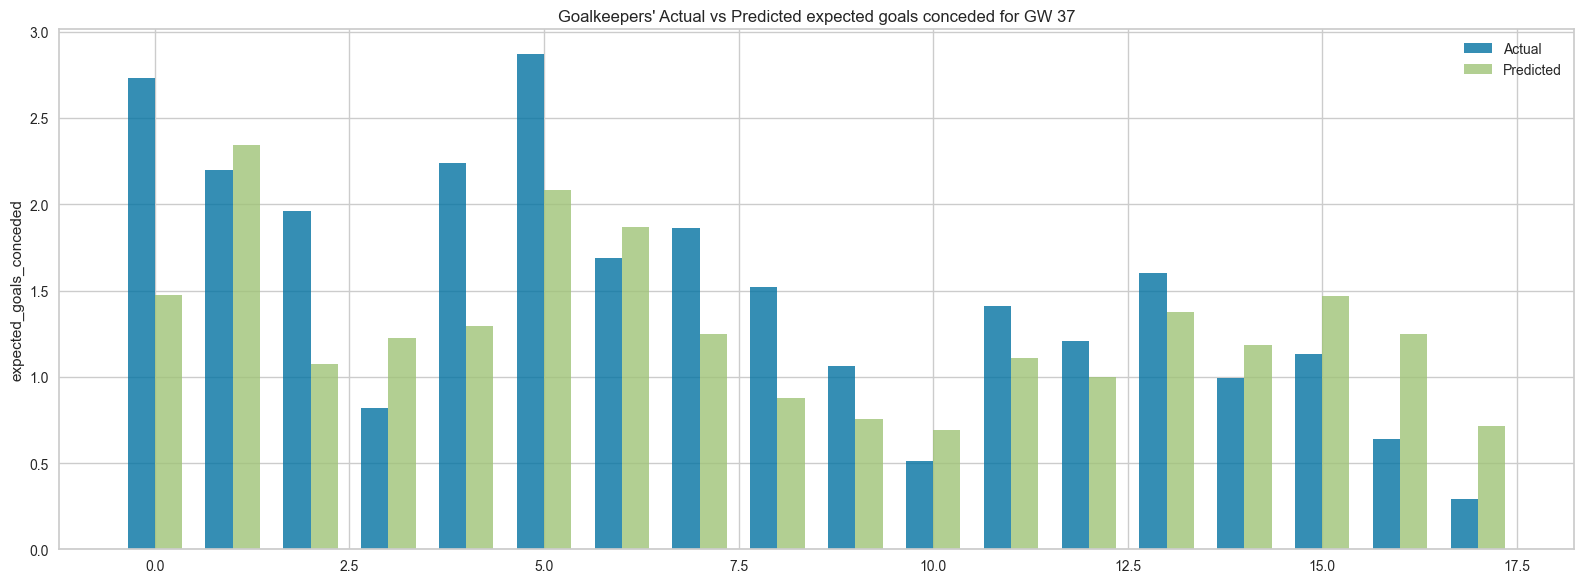

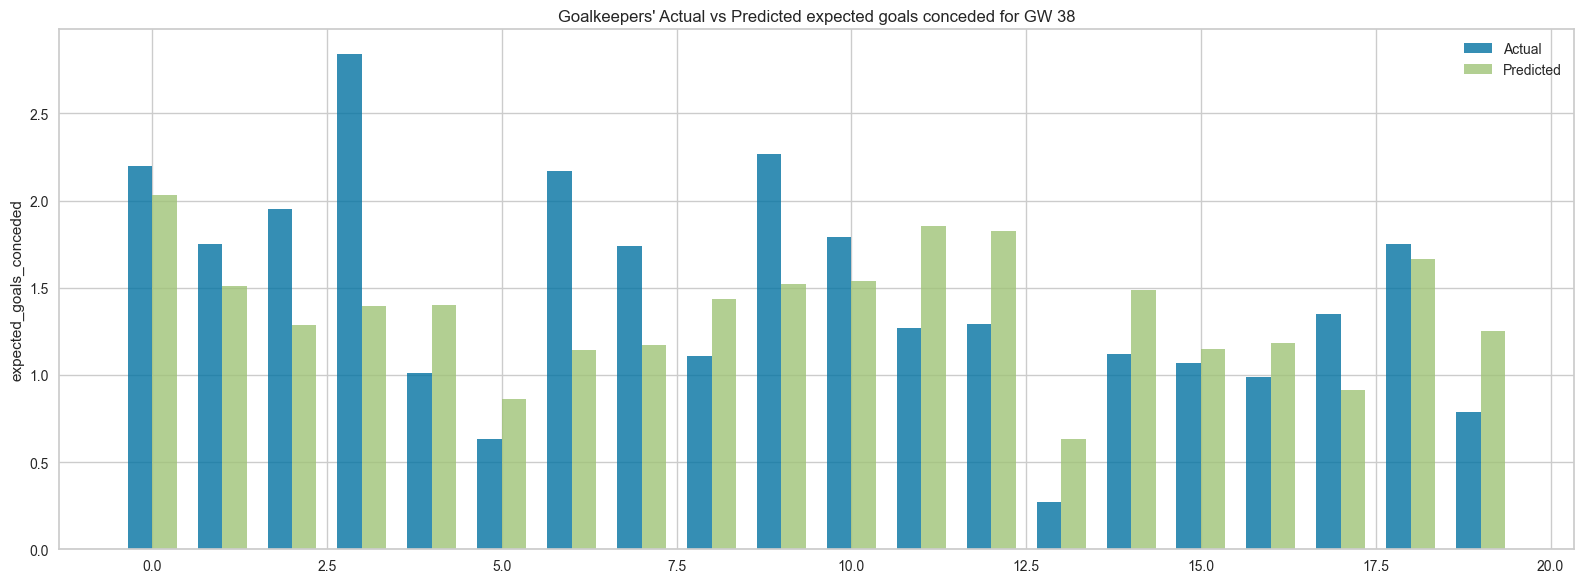

Transformation Pipeline and Model Successfully Loaded


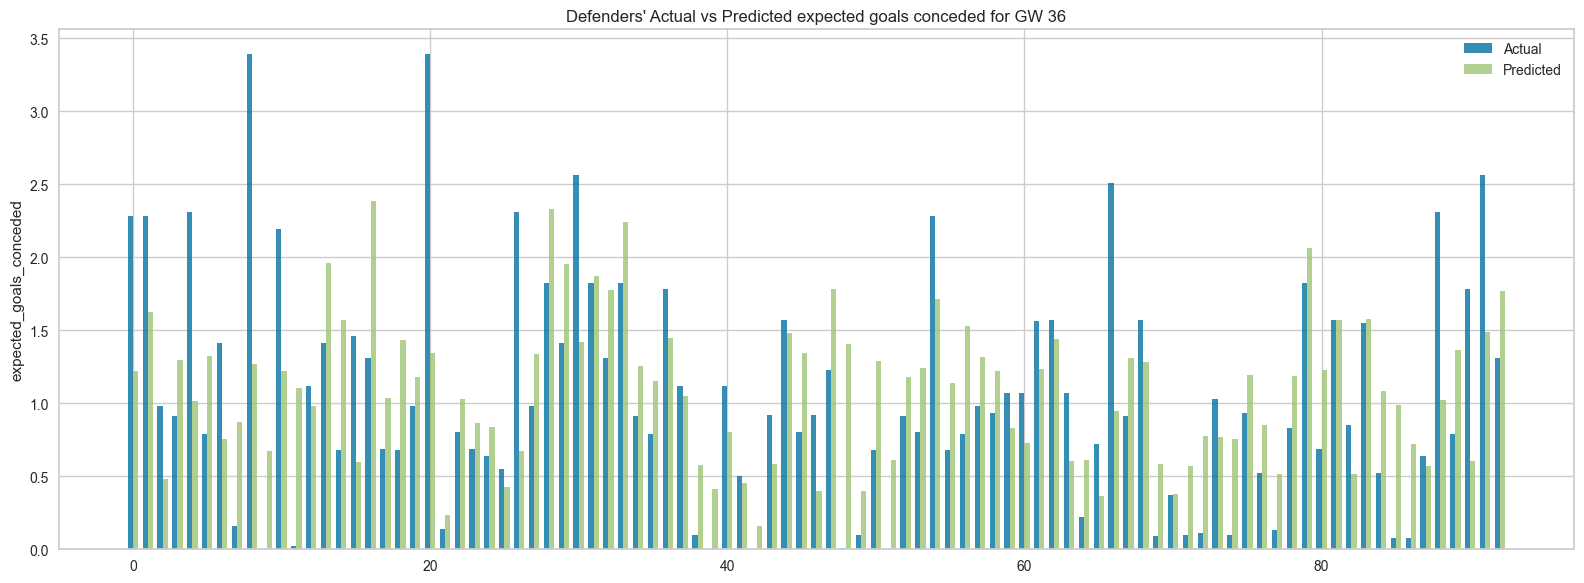

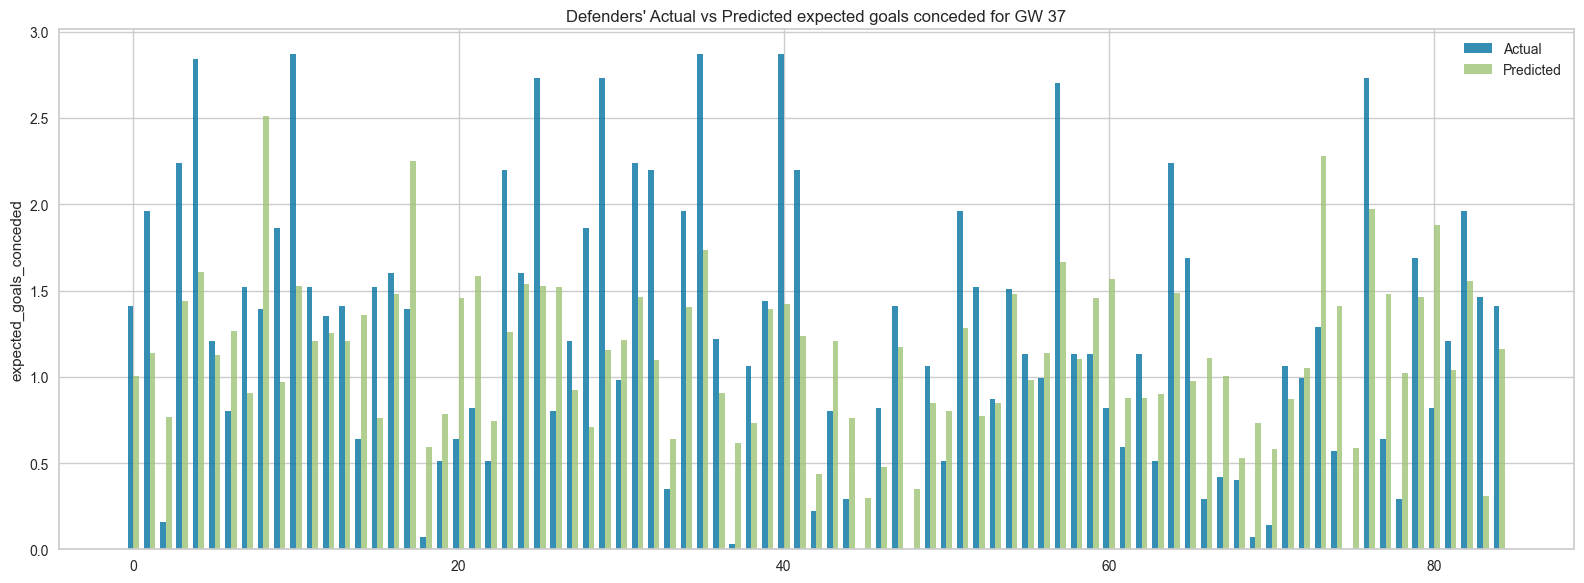

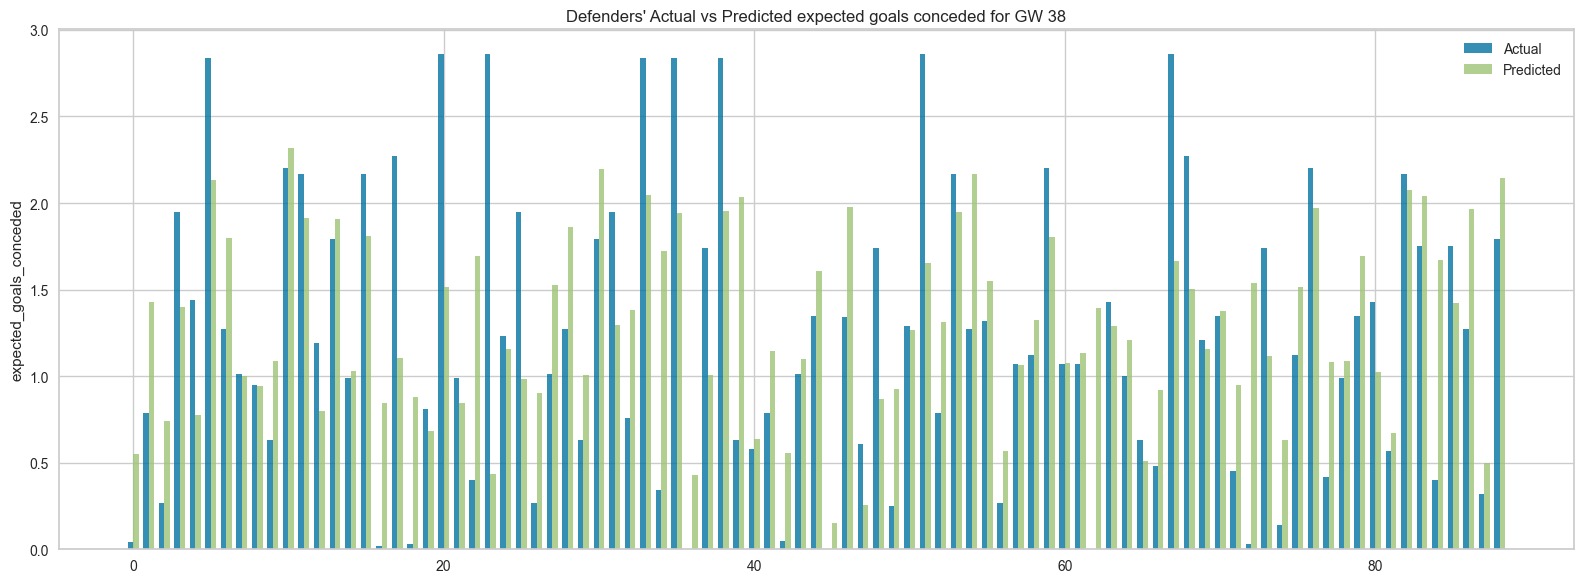

Transformation Pipeline and Model Successfully Loaded


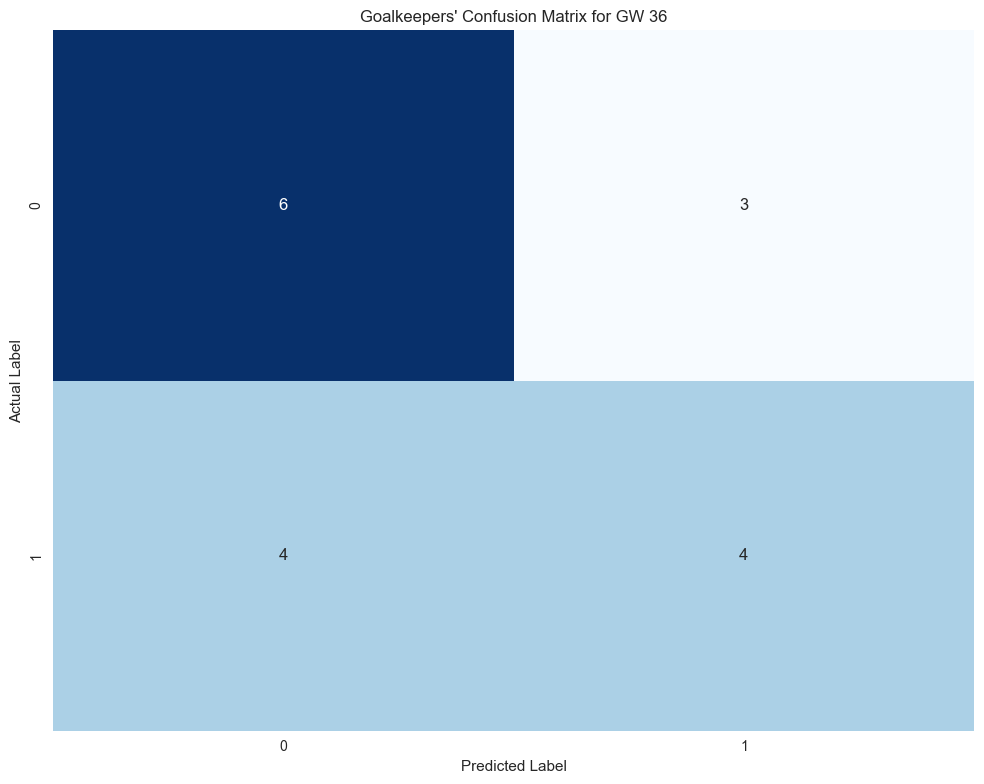

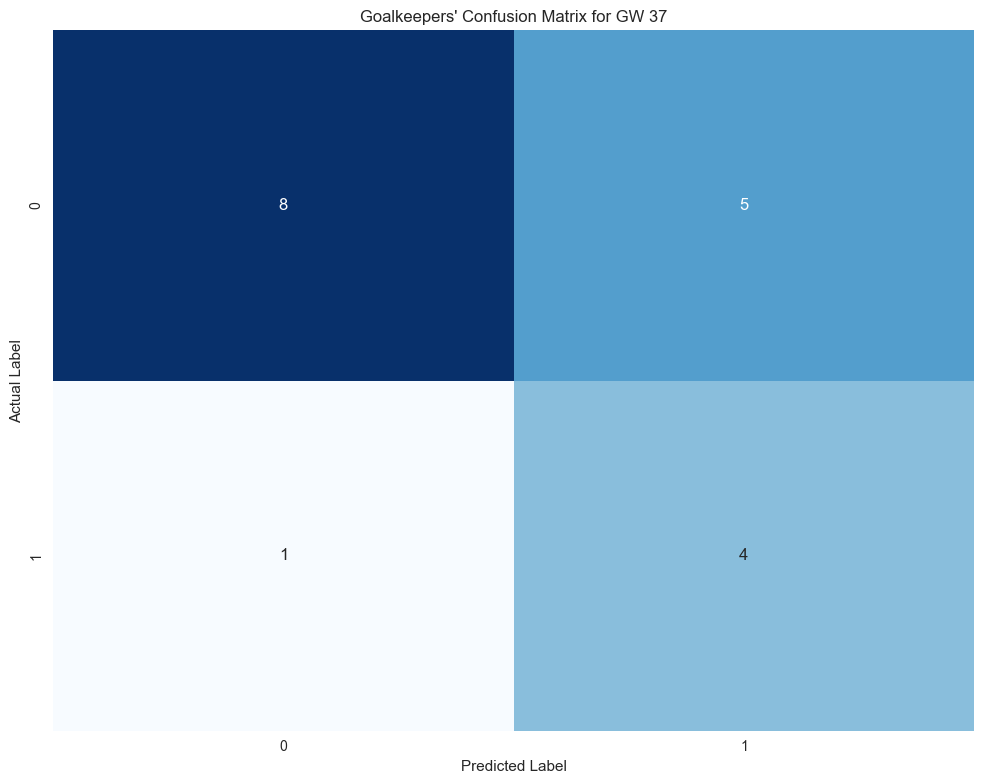

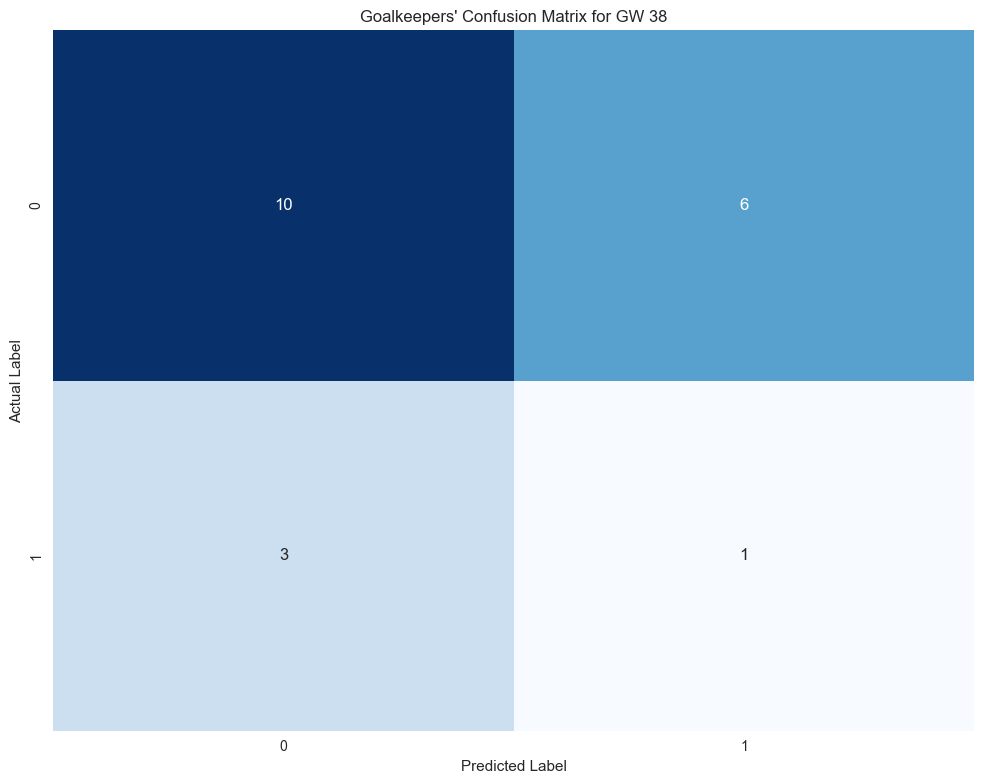

Transformation Pipeline and Model Successfully Loaded


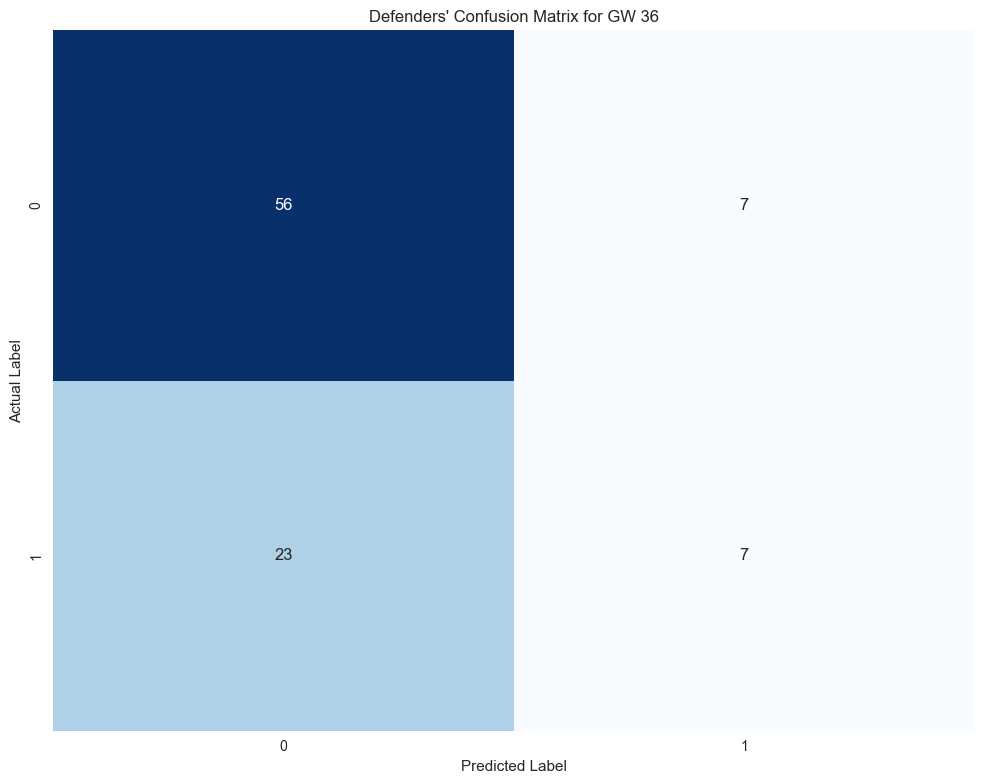

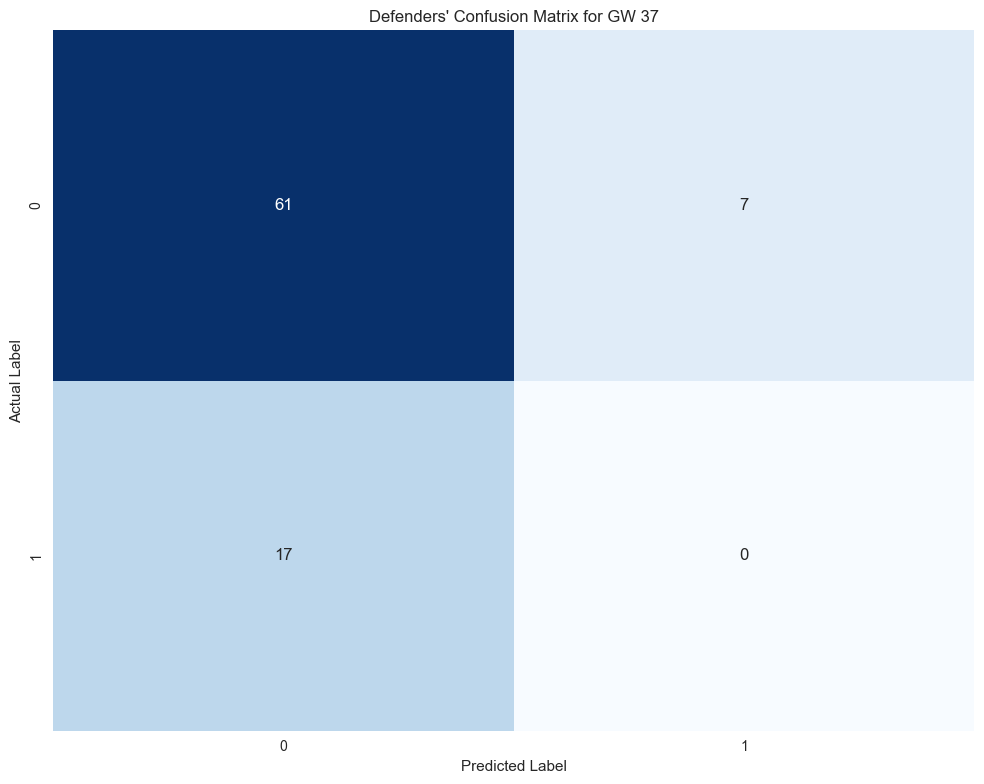

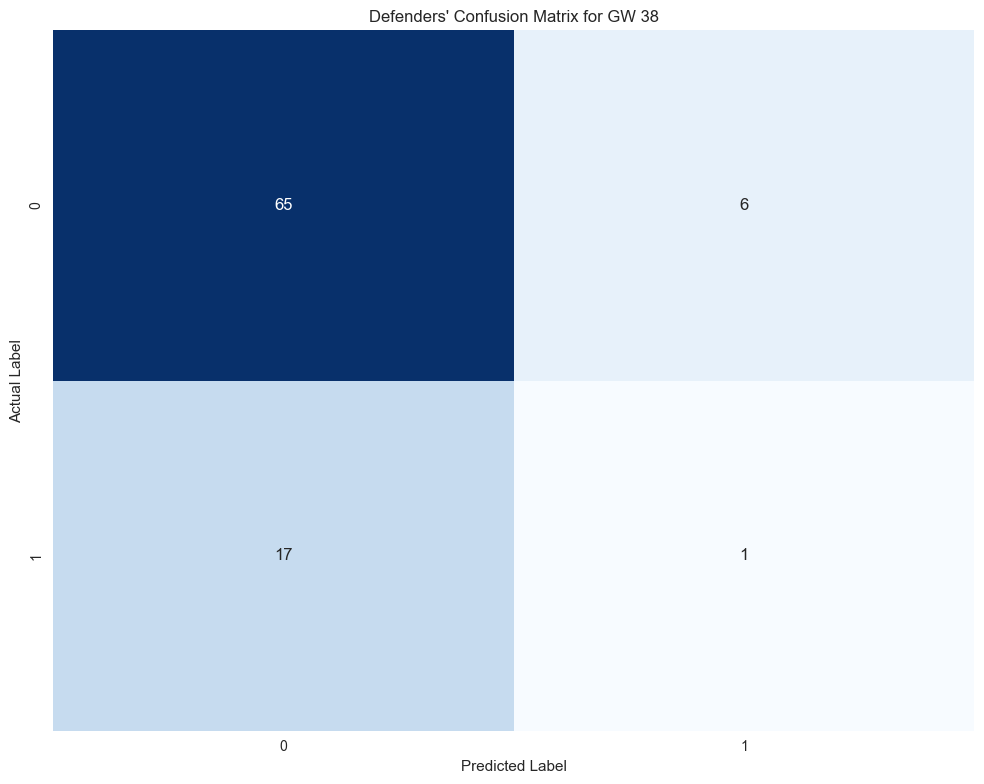

Transformation Pipeline and Model Successfully Loaded


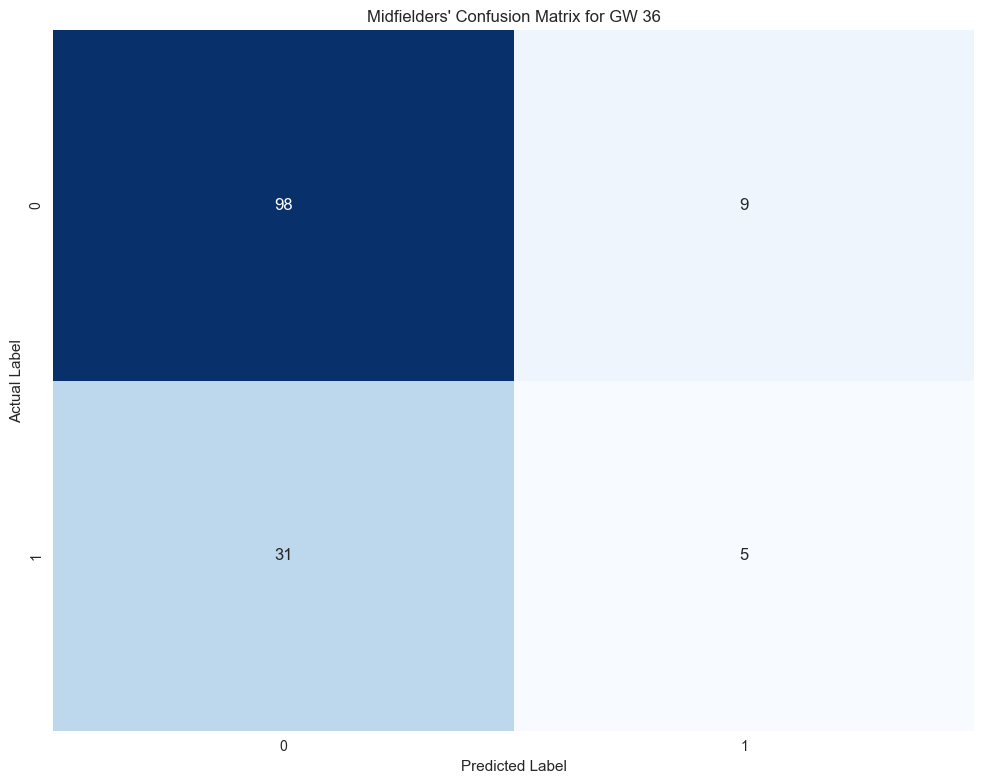

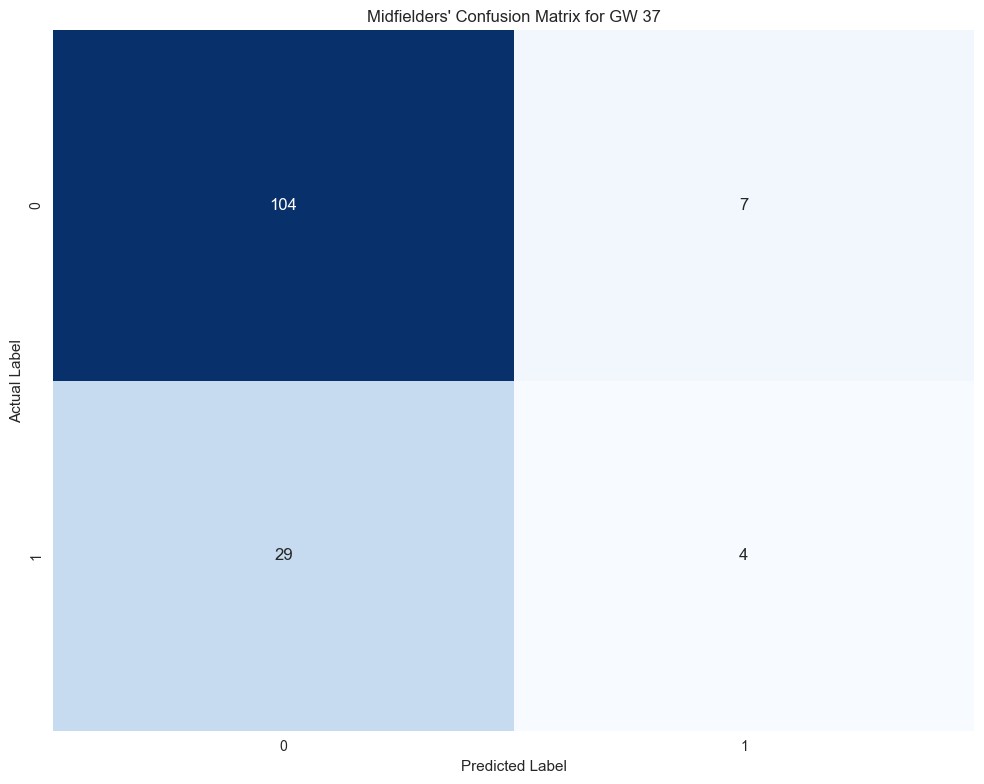

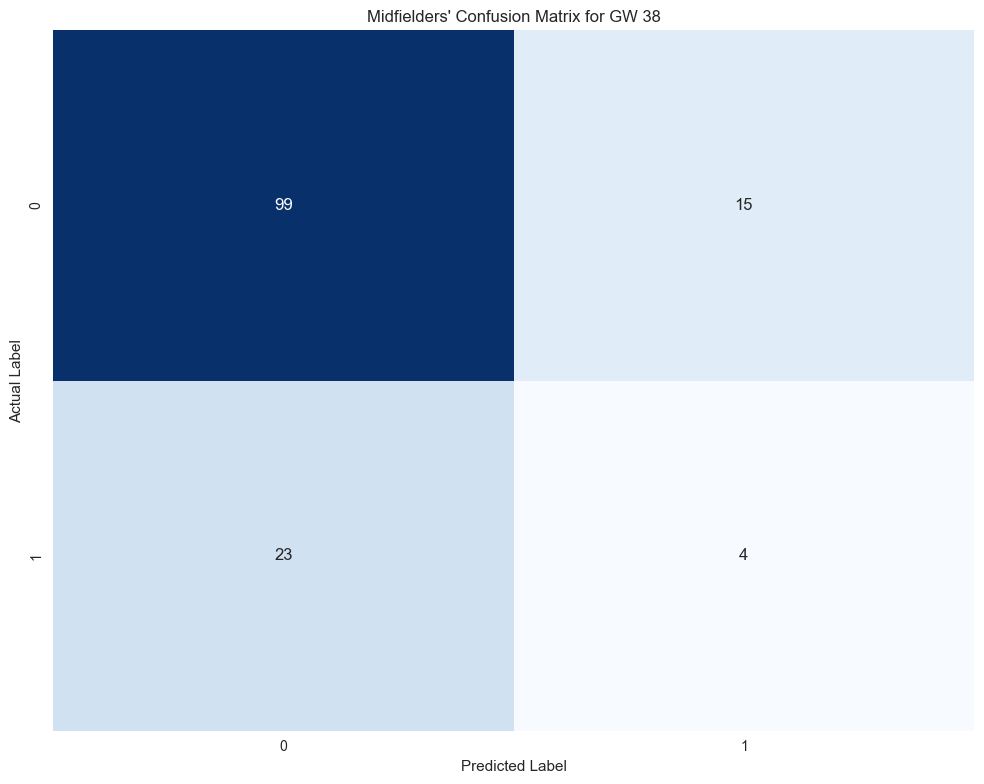

Transformation Pipeline and Model Successfully Loaded


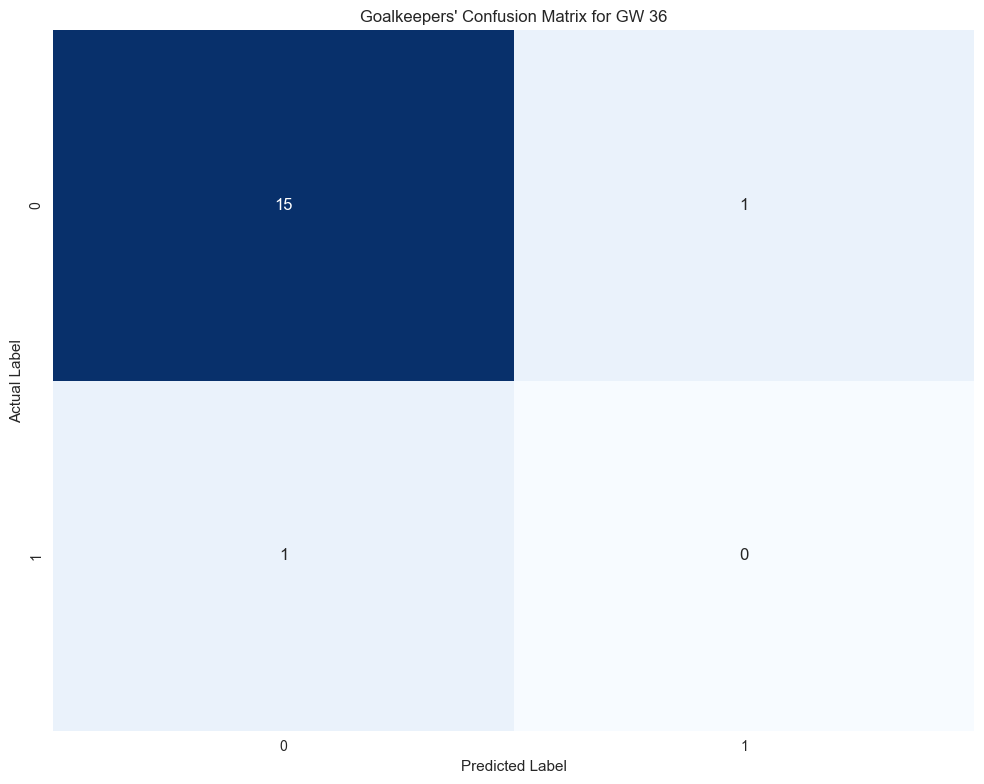

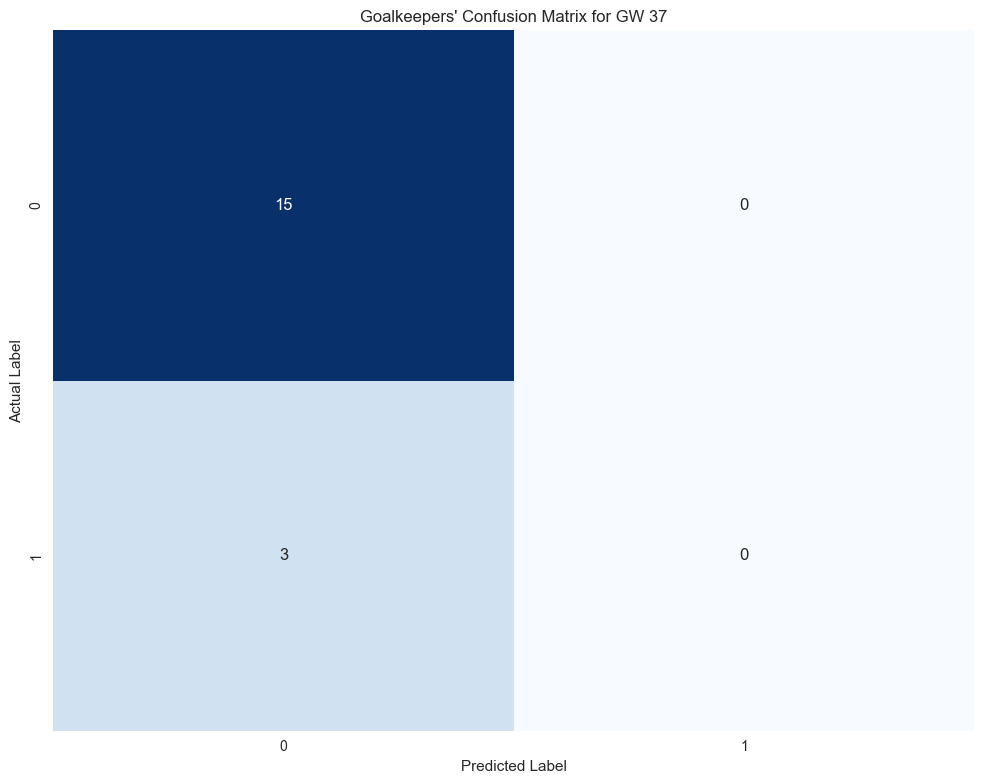

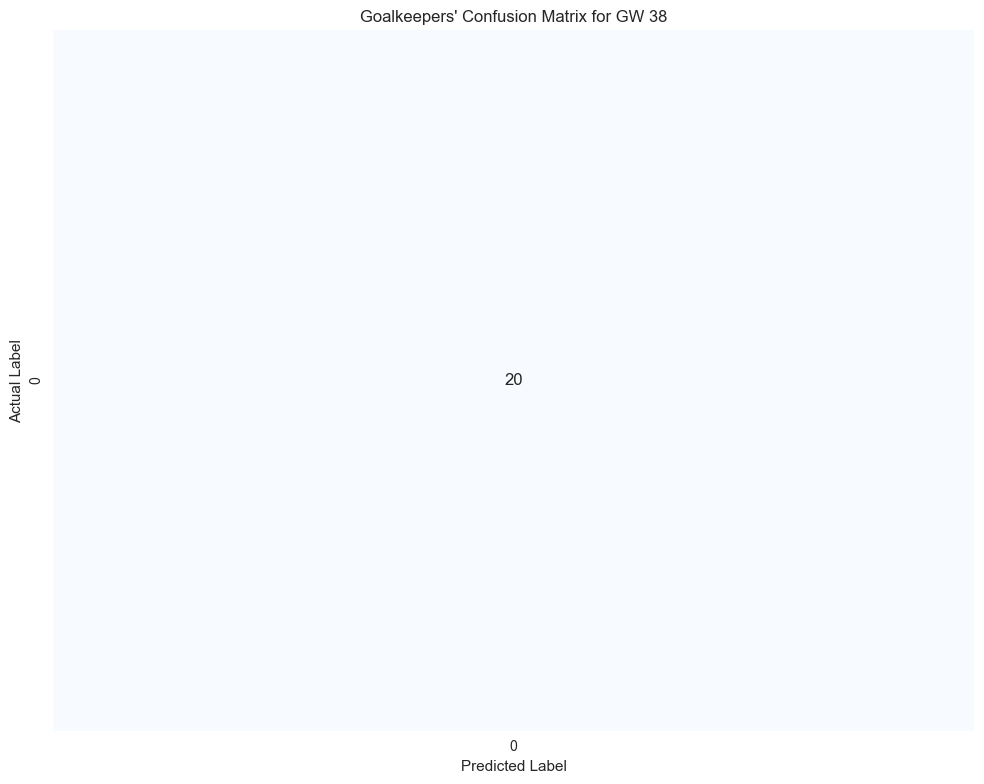

Transformation Pipeline and Model Successfully Loaded


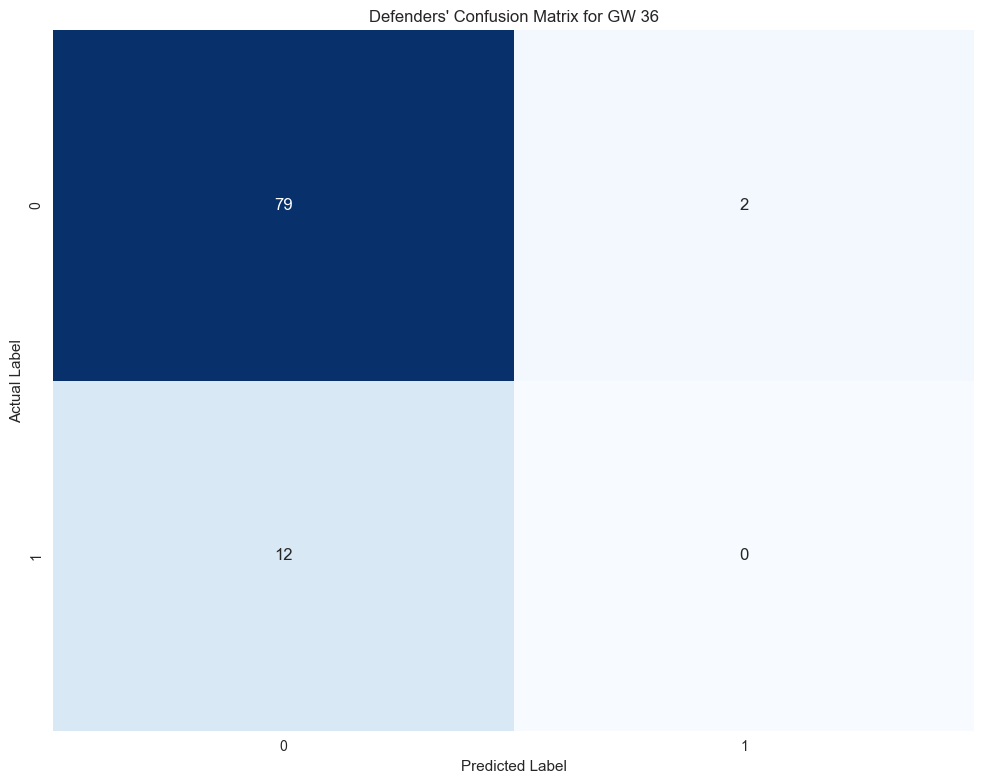

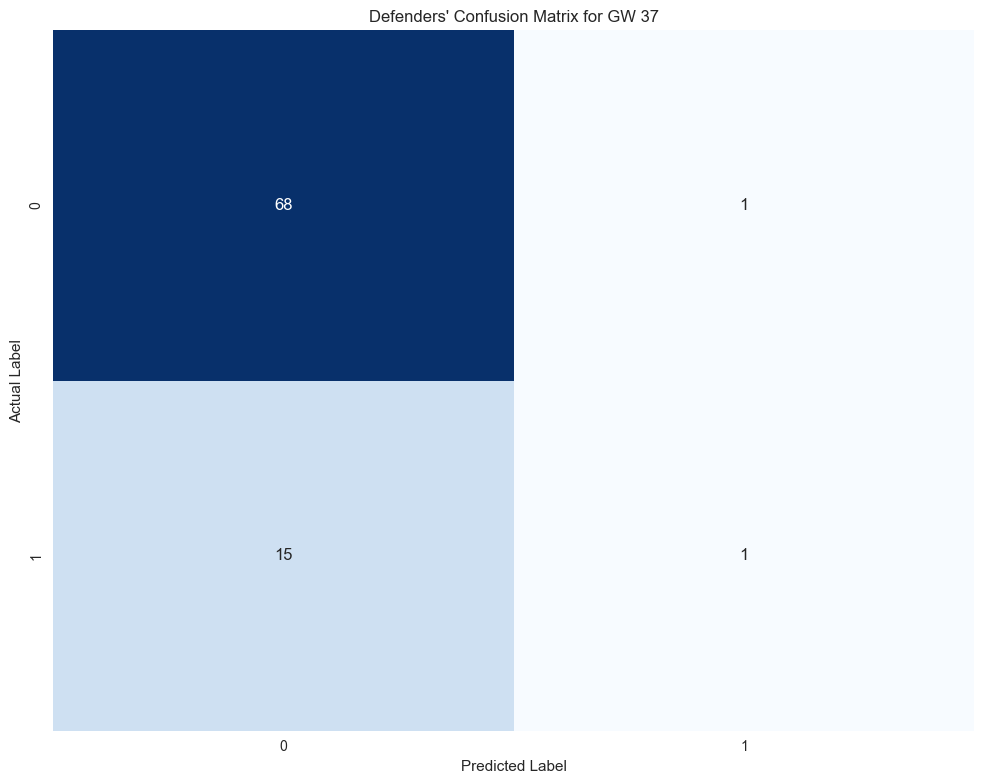

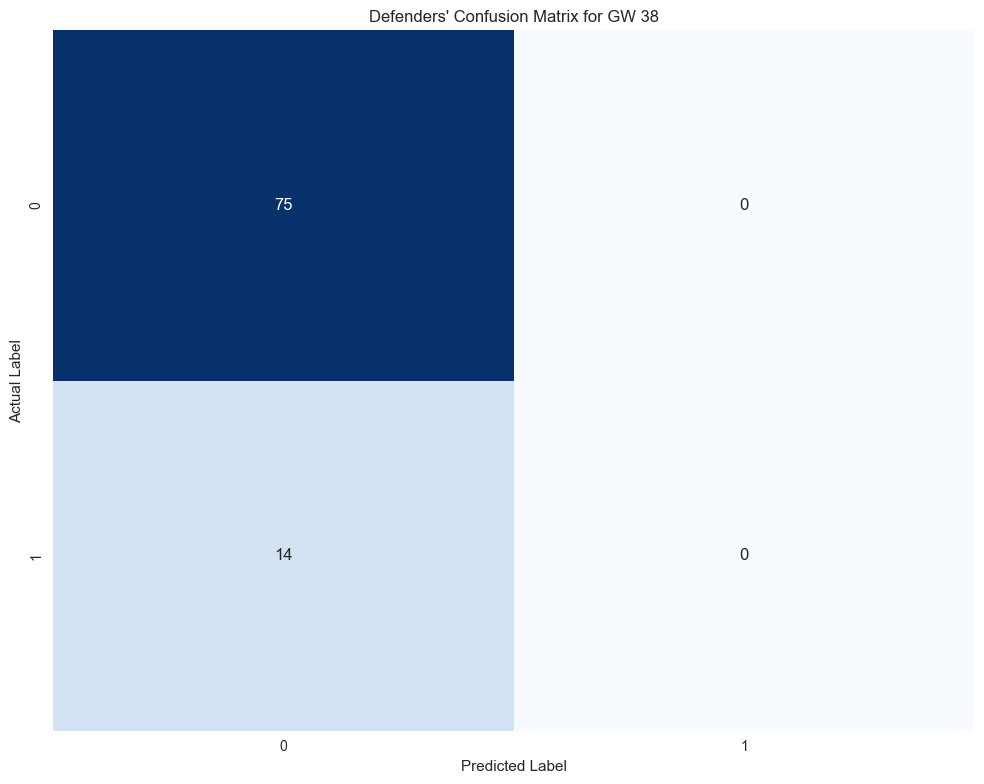

Transformation Pipeline and Model Successfully Loaded


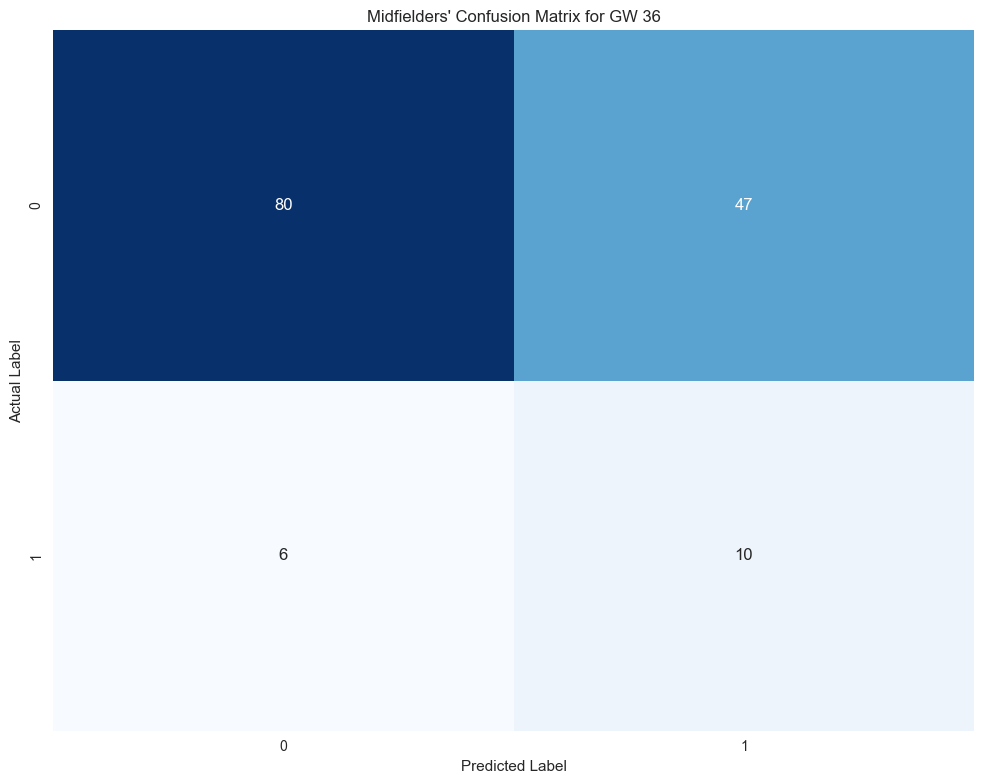

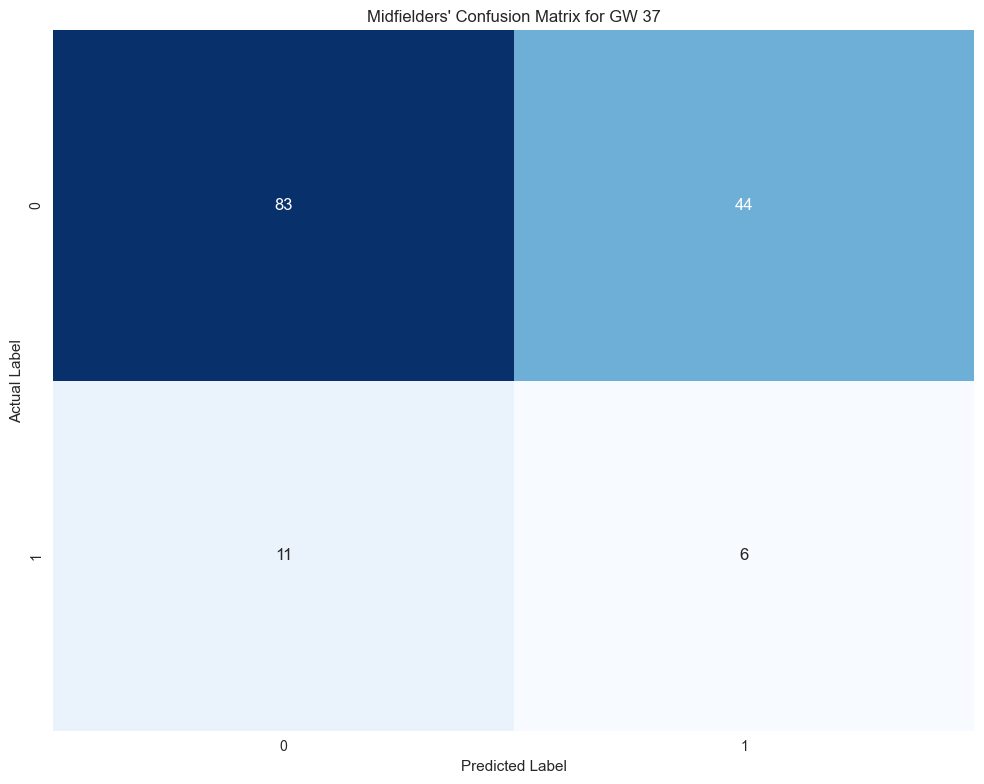

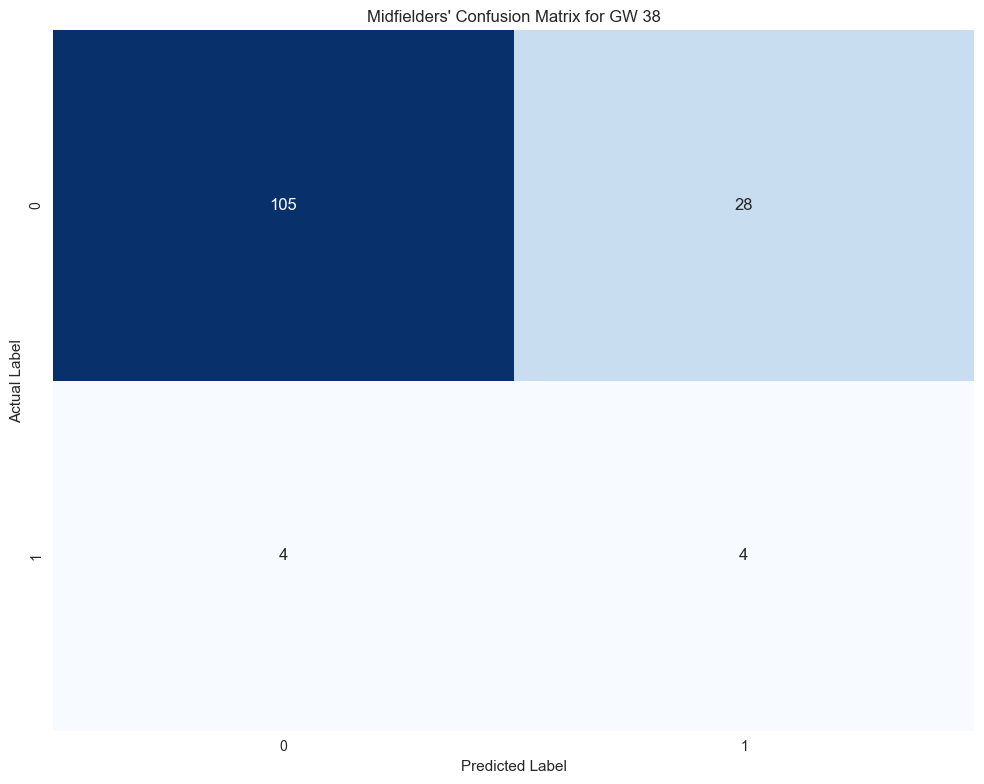

Transformation Pipeline and Model Successfully Loaded


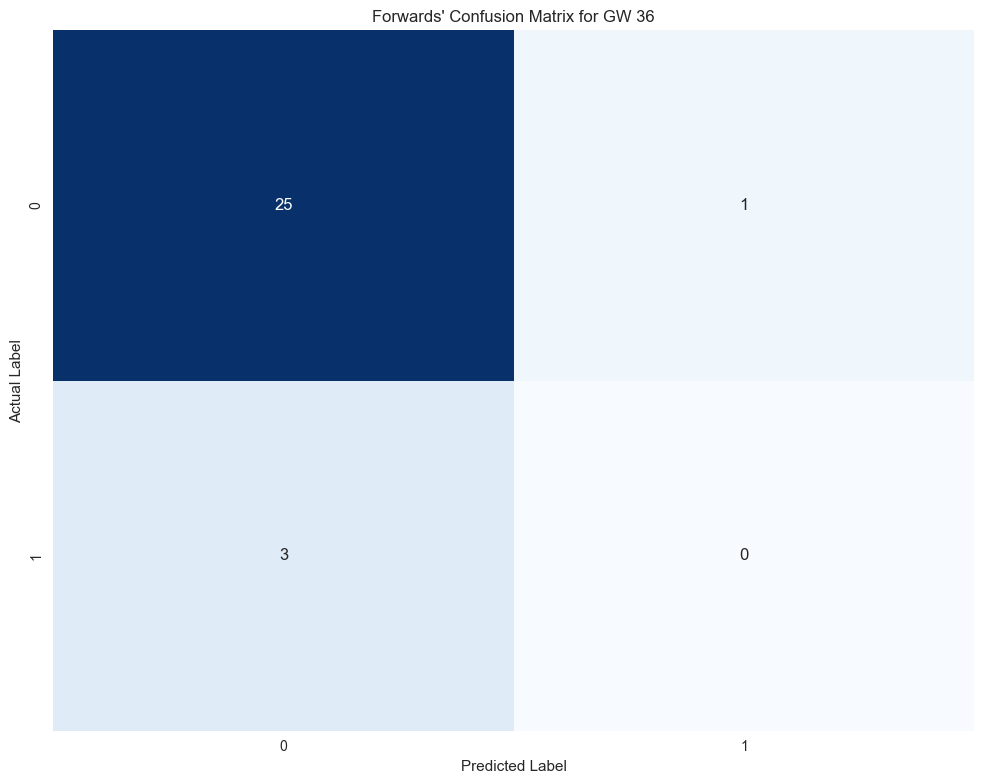

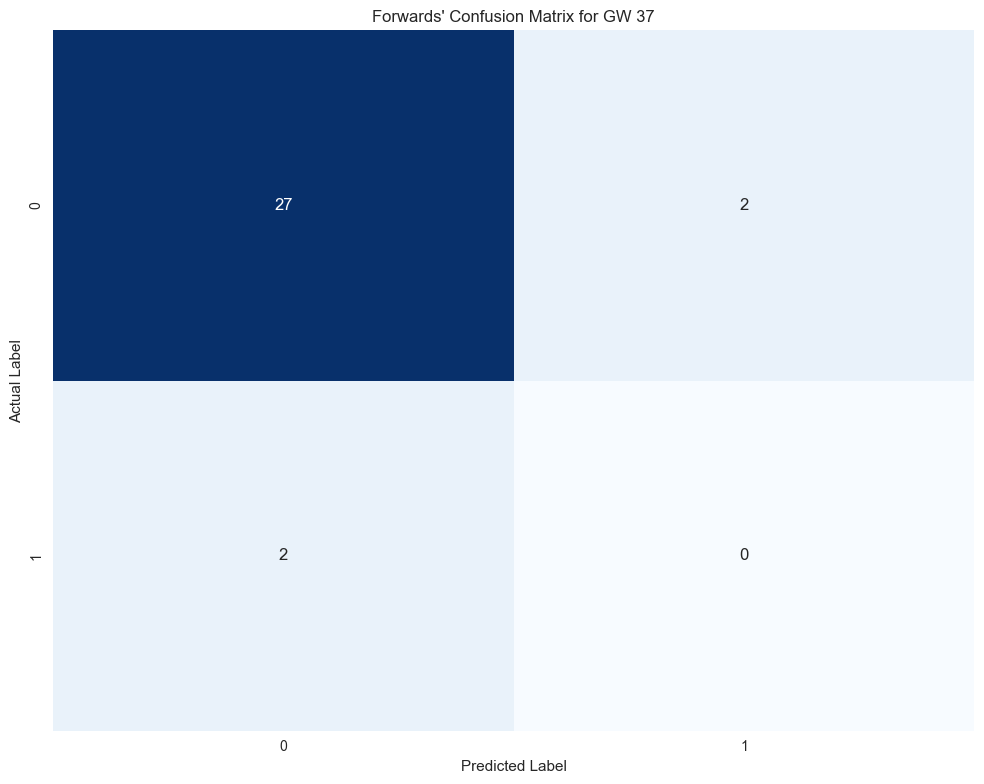

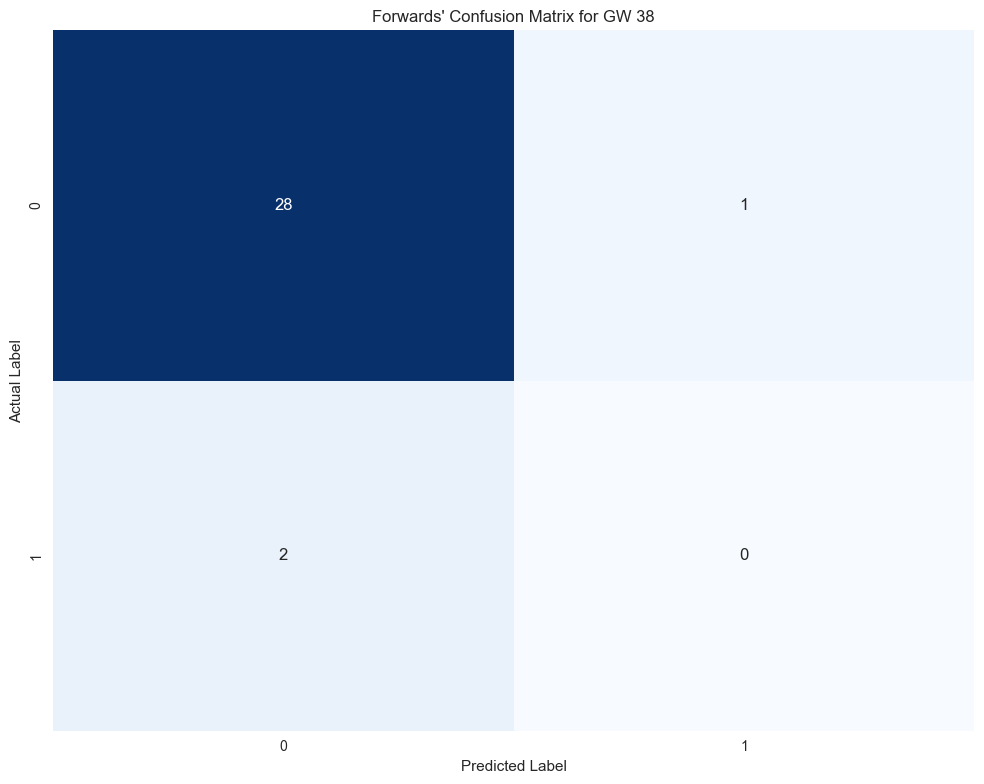

In [74]:
%run ./regression_predictor.ipynb
%run ./classifier_predictor.ipynb

# Fetch predictions


In [75]:
data_36 = pd.read_csv('./data_36_with_preds.csv', index_col=0)
data_37 = pd.read_csv('./data_37_with_preds.csv', index_col=0)
data_38 = pd.read_csv('./data_38_with_preds.csv', index_col=0)

In [76]:
def calc_xP_pred(row):
    # Minutes played bonus
    if row['minutes_3'] >= 60:
        minutes_bonus = 2
    elif row['minutes_3'] > 0:
        minutes_bonus = 1
    else:
        minutes_bonus = 0  # if player didn't play at all
    if row['position'] == 'GK':

        ## GK
        ## ---> >60  = 2
        ## ---> cs*4
        ## ---> ((sv)/3)*1
        ## ---> (gc/2)*-1
        ## ---> yc*-1
        return (
            minutes_bonus +
            4 * row['cs_preds'] +
            1 * round(row['saves_preds']/3, 3) -
            1 * round(row['xgc_preds']/2, 3) -
            1 * row['y_preds']
        )

    elif row['position'] == 'DEF':
        ## DEF
        ## ---> >60  = 2
        ## ---> xg*6
        ## ---> xa*3
        ## ---> cs*4
        ## ---> gc
        ## ---> yc*-1


        return (
            minutes_bonus +
            6 * row['xG_preds'] +
            3 * row['xA_preds'] +
            4 * row['cs_preds'] -
            1 * round(row['xgc_preds']/2, 3) -
            1 * row['y_preds']
        )
    elif row['position'] == 'MID':
        ## MID
        ## ---> >60  = +2
        ## ---> xg*5
        ## ---> xa*3
        ## ---> cs*1
        ## ---> yc*-1

        return (
            minutes_bonus +
            5 * row['xG_preds'] +
            3 * row['xA_preds'] +
            1 * row['cs_preds'] -
            1 * row['y_preds']
        )
    elif row['position'] == 'FWD':
        ## FWD
        ## ---> >60  = 2
        ## ---> xg*4
        ## ---> xa*3
        ## ---> yc*-1
        return (
            minutes_bonus +
            4 * row['xG_preds'] +
            3 * row['xA_preds'] -
            1 * row['y_preds']
        )
    else:
        return 0  # fallback for unknown positions


data_36['xP_preds'] = data_36.apply(calc_xP_pred, axis=1)
data_37['xP_preds'] = data_37.apply(calc_xP_pred, axis=1)
data_38['xP_preds'] = data_38.apply(calc_xP_pred, axis=1)

In [77]:
id_name_df = pd.read_csv('../../fpl_understat_id_name.csv')

def add_player_name(row):
    # Check if fpl_id exists in id_name_df
    player_row = id_name_df[id_name_df['fpl_id'] == row['element']]
    if not player_row.empty:
        return player_row.iloc[0]['fpl_name'], player_row.iloc[0]['understat_name'], player_row.iloc[0]['team']
    else:
        return None

data_36[['fpl_name', 'understat_name', 'team']] = data_36.apply(add_player_name, axis=1, result_type='expand')
data_37[['fpl_name', 'understat_name', 'team']] = data_37.apply(add_player_name, axis=1, result_type='expand')
data_38[['fpl_name', 'understat_name', 'team']] = data_38.apply(add_player_name, axis=1, result_type='expand')

data_36.to_csv('./players_preds_36.csv', index=True)
data_37.to_csv('./players_preds_37.csv', index=True)
data_38.to_csv('./players_preds_38.csv', index=True)


# Plots


## GW 36


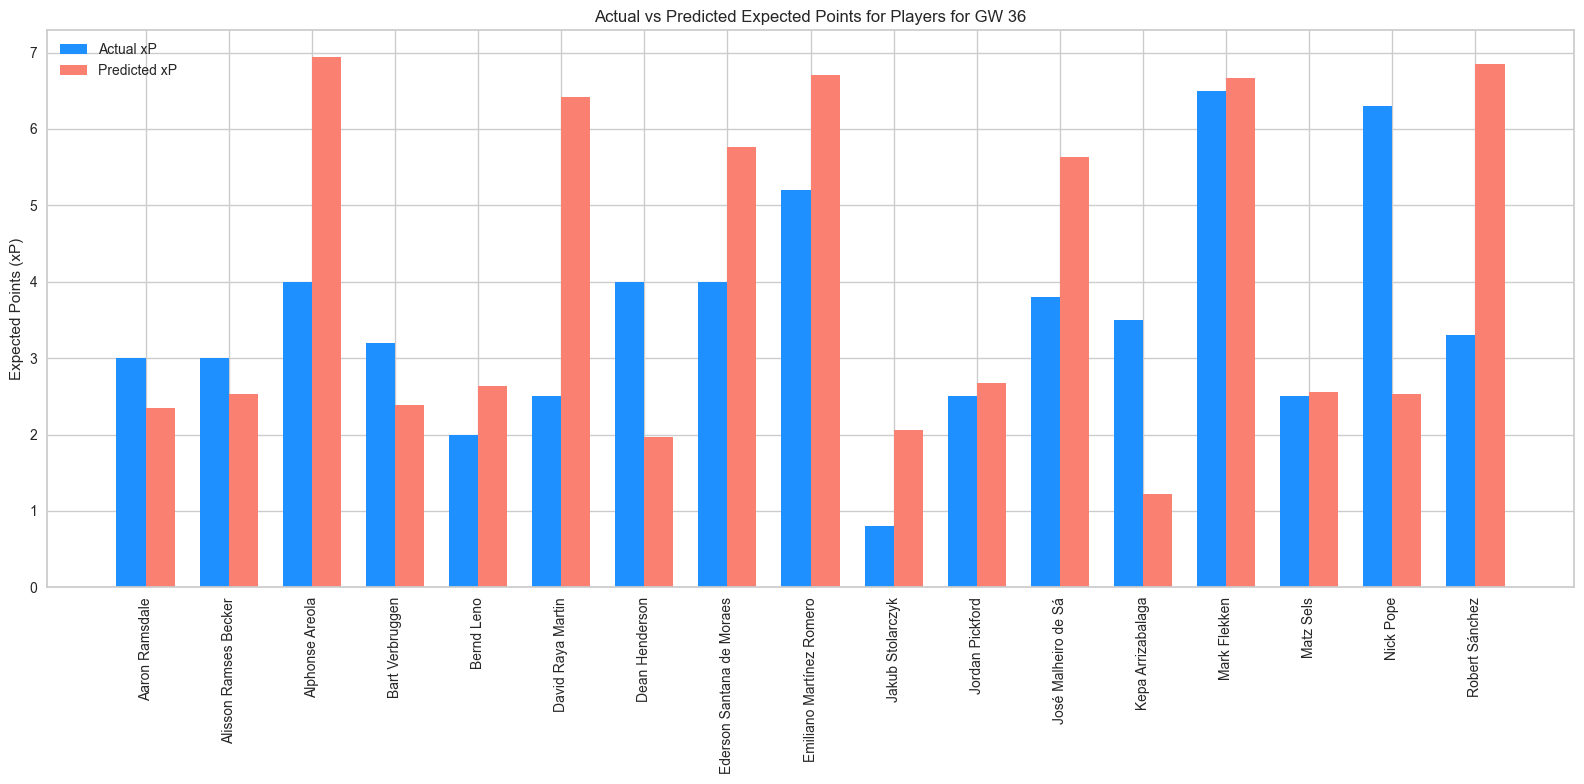

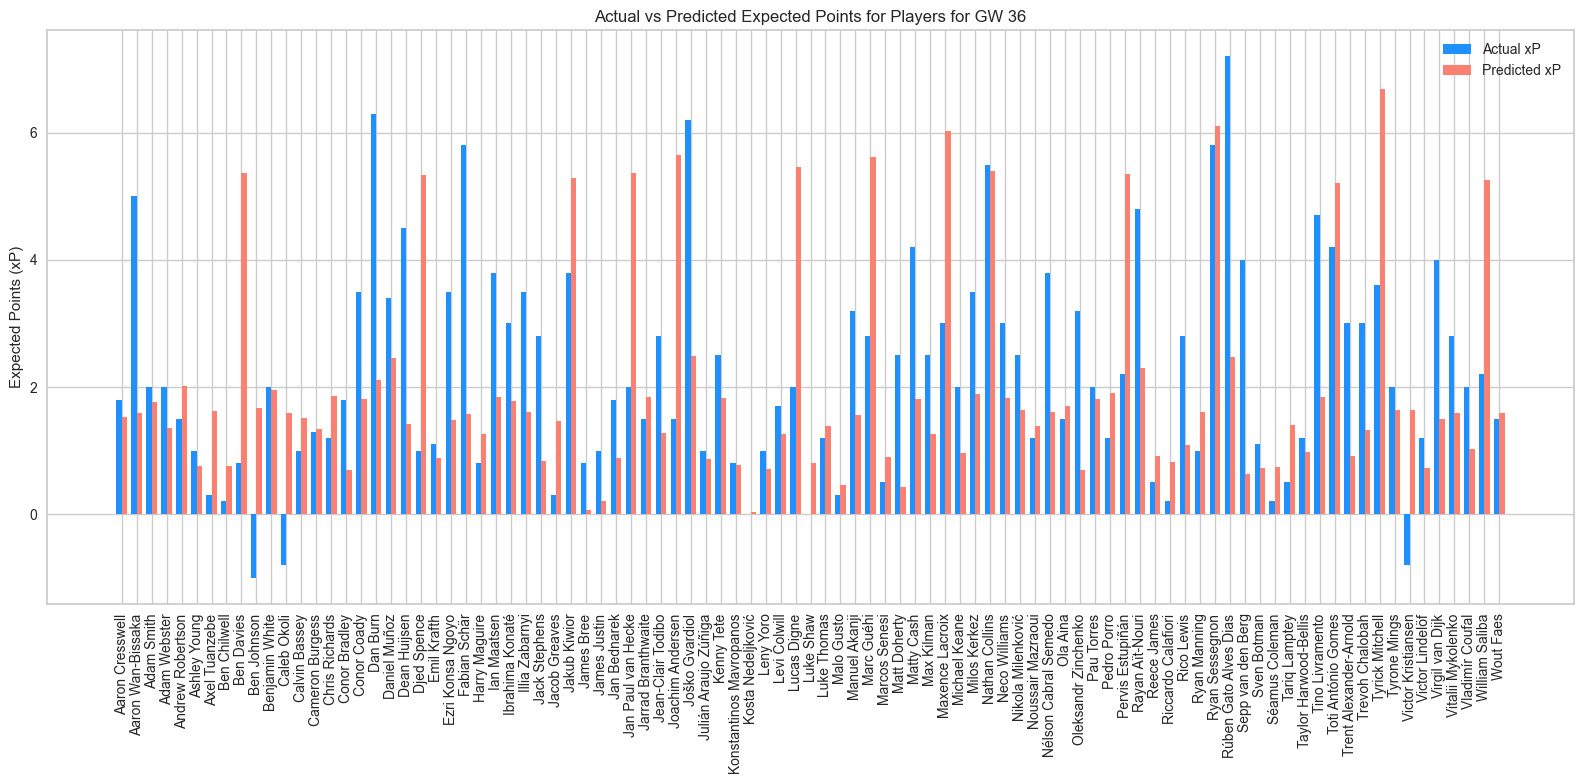

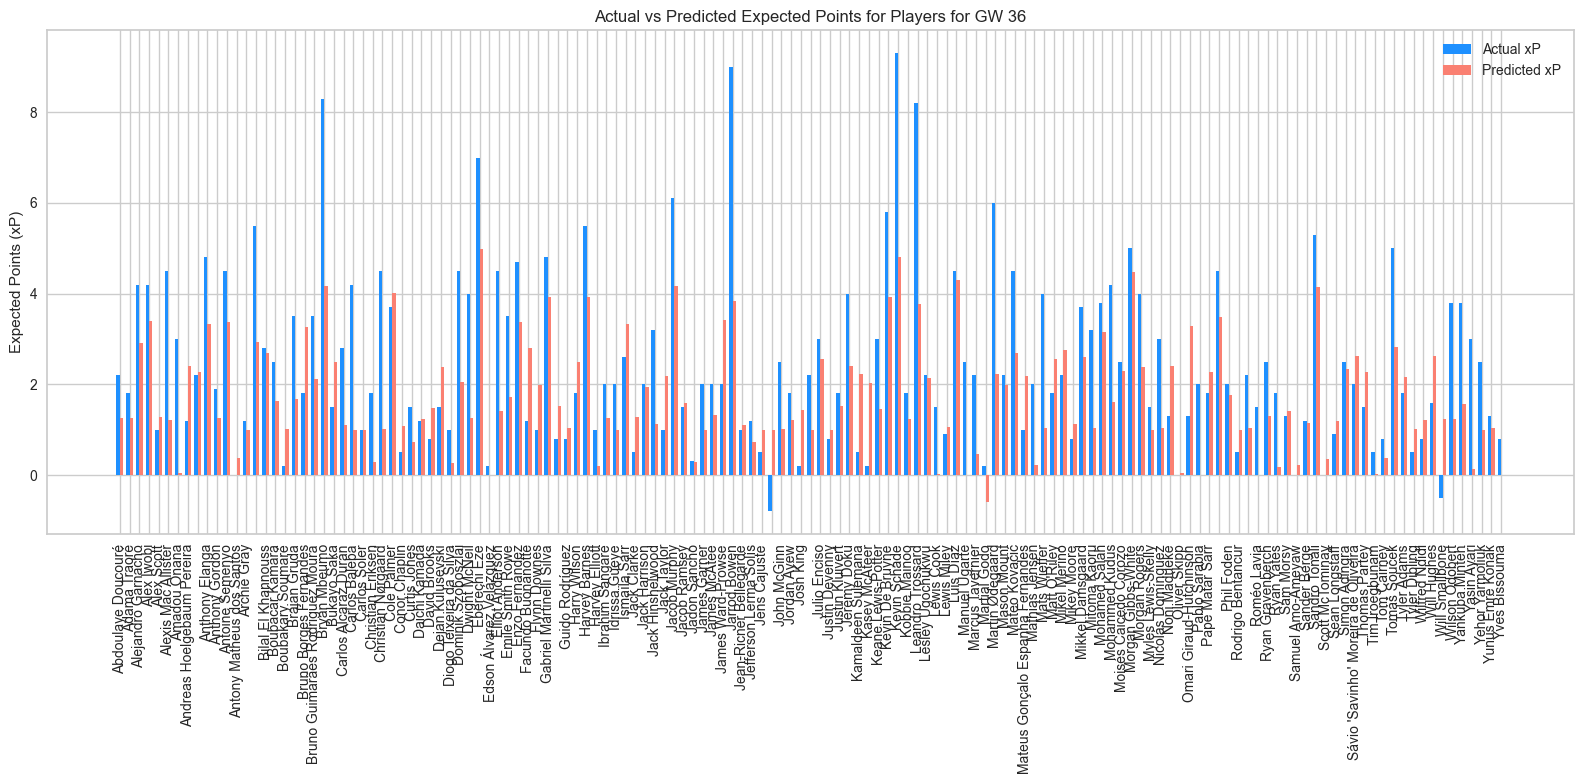

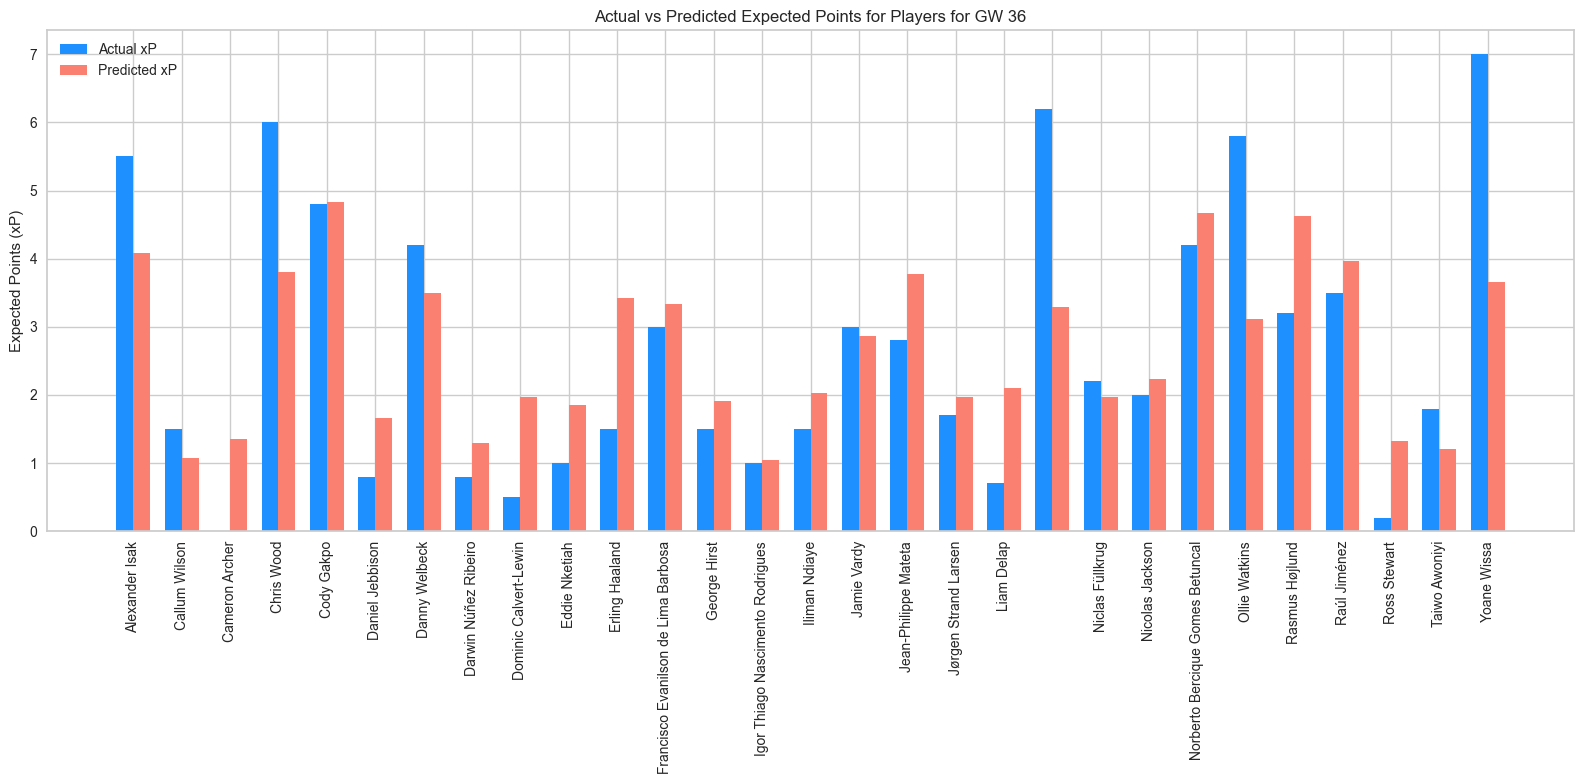

In [78]:
gk_36 = data_36[data_36['position'] == 'GK']
def_36 = data_36[data_36['position'] == 'DEF']
mid_36 = data_36[data_36['position'] == 'MID']
fwd_36 = data_36[data_36['position'] == 'FWD']


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(gk_36['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, gk_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, gk_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 36')
plt.xticks(x, gk_36['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(def_36['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, def_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, def_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 36')
plt.xticks(x, def_36['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(mid_36['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, mid_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, mid_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 36')
plt.xticks(x, mid_36['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(fwd_36['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, fwd_36['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, fwd_36['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 36')
plt.xticks(x, fwd_36['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

## GW 37


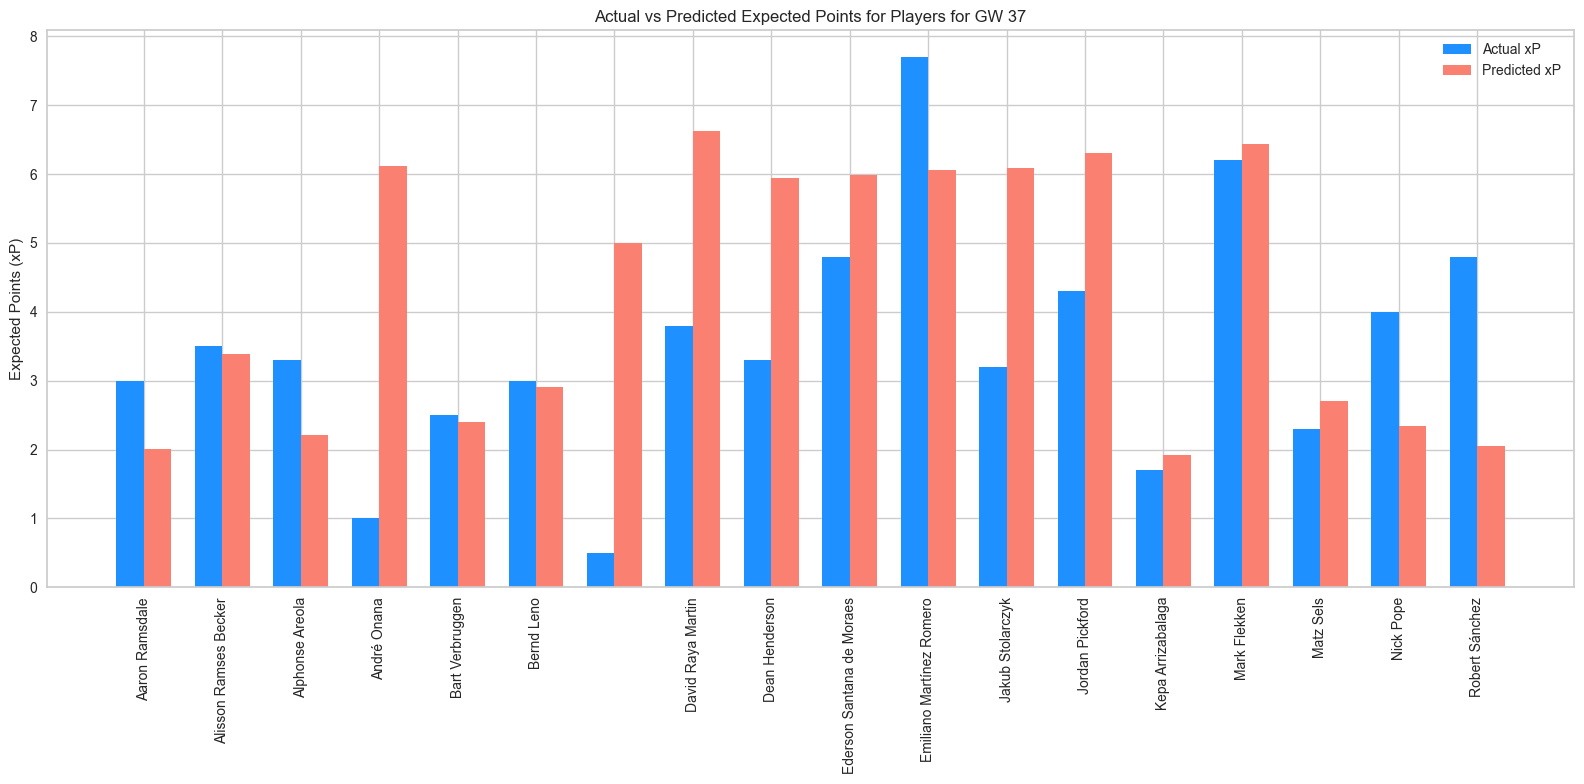

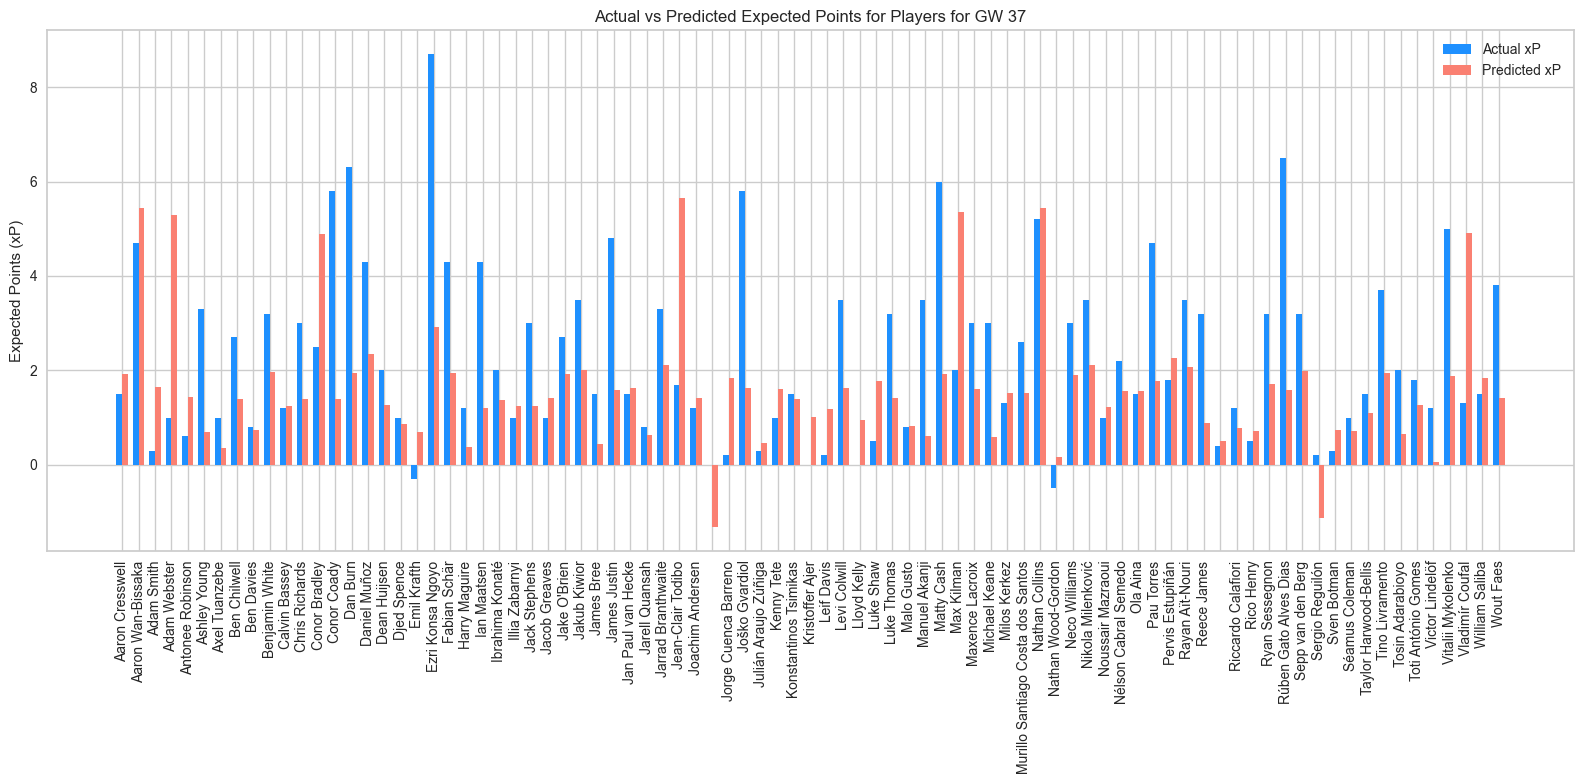

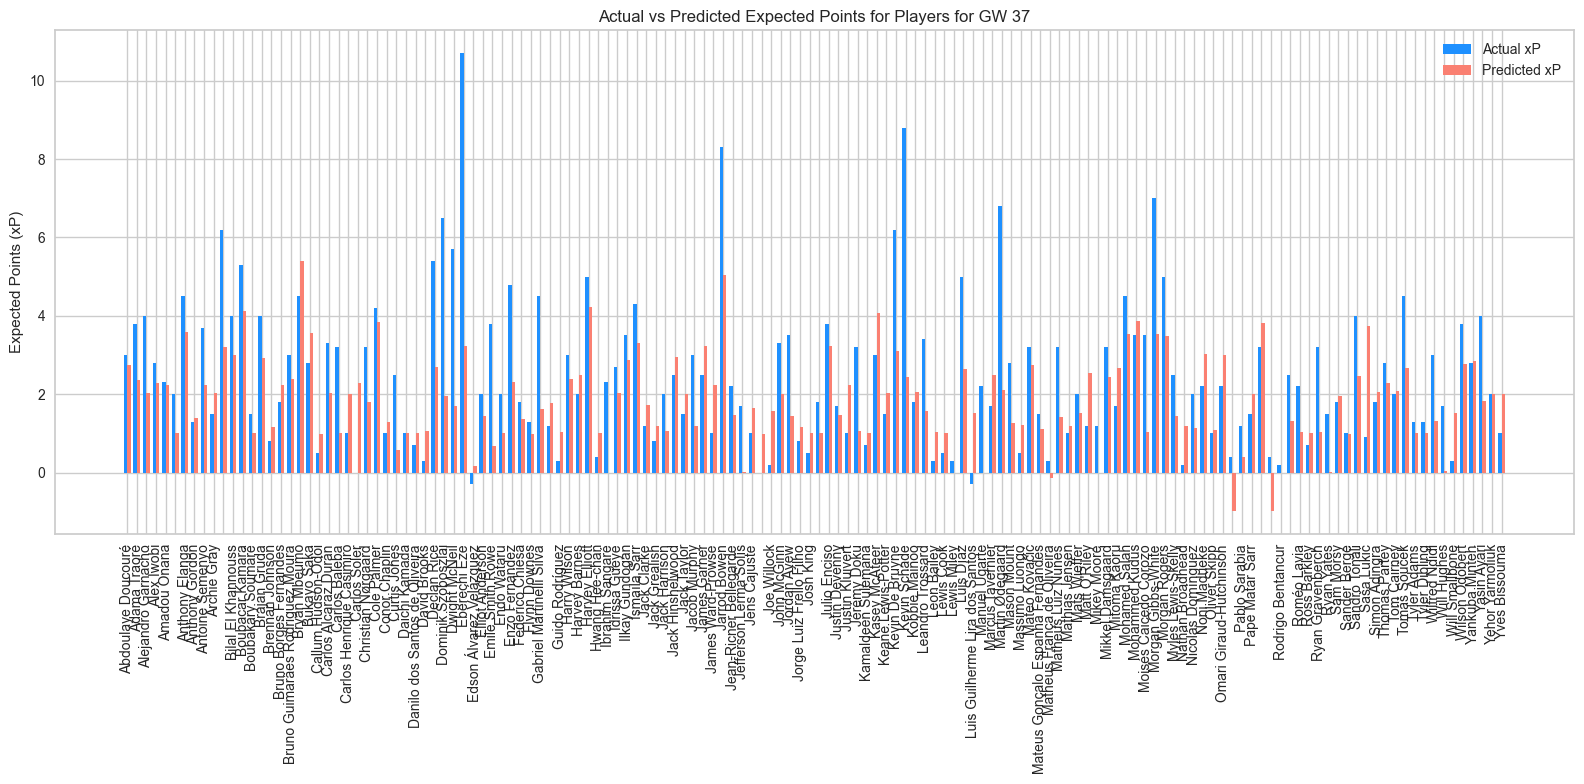

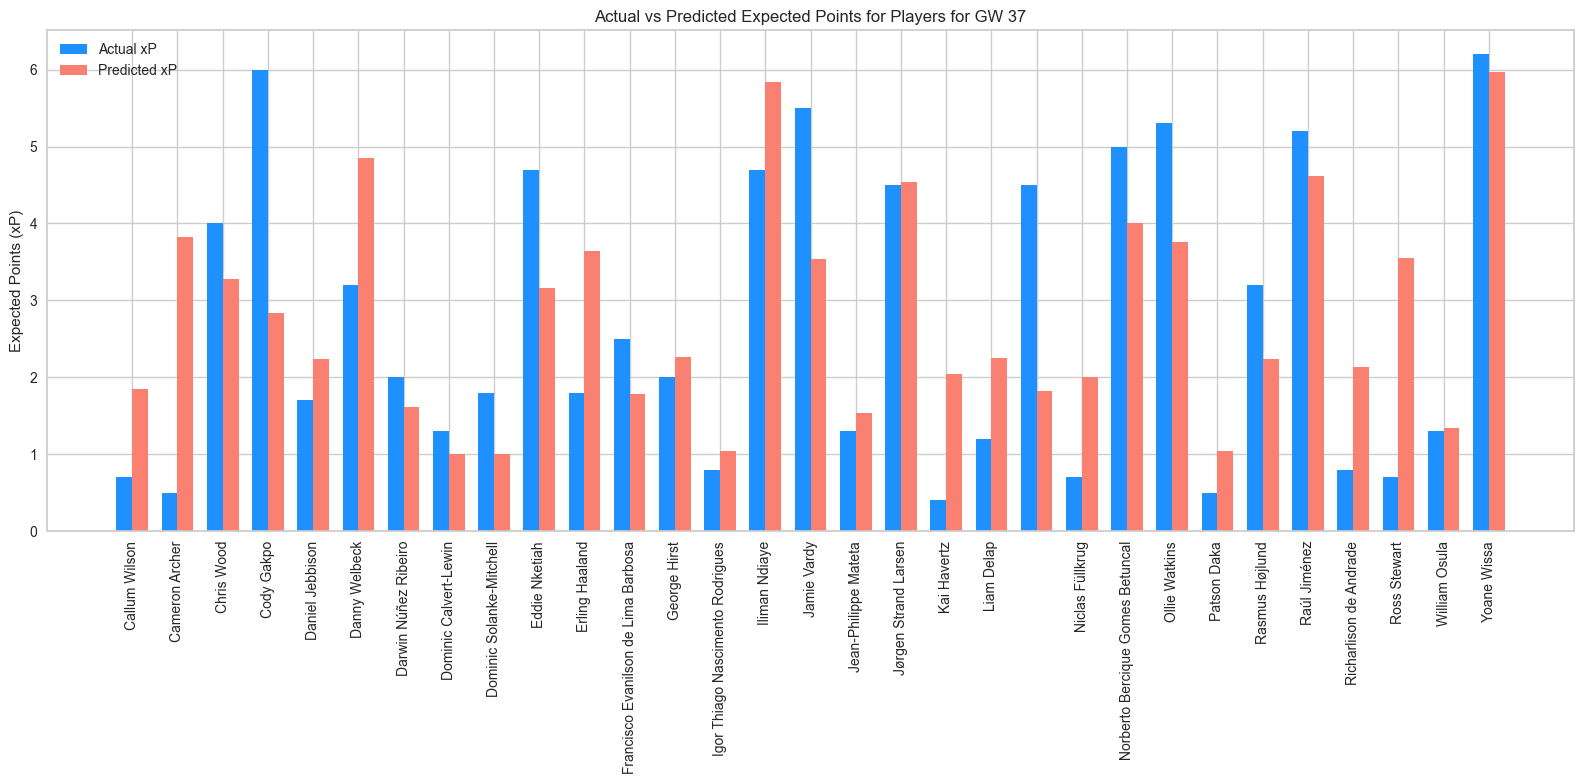

In [79]:
gk_37 = data_37[data_37['position'] == 'GK']
def_37 = data_37[data_37['position'] == 'DEF']
mid_37 = data_37[data_37['position'] == 'MID']
fwd_37 = data_37[data_37['position'] == 'FWD']


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(gk_37['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, gk_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, gk_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 37')
plt.xticks(x, gk_37['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(def_37['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, def_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, def_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 37')
plt.xticks(x, def_37['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(mid_37['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, mid_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, mid_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 37')
plt.xticks(x, mid_37['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(fwd_37['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, fwd_37['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, fwd_37['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 37')
plt.xticks(x, fwd_37['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

## GW 38


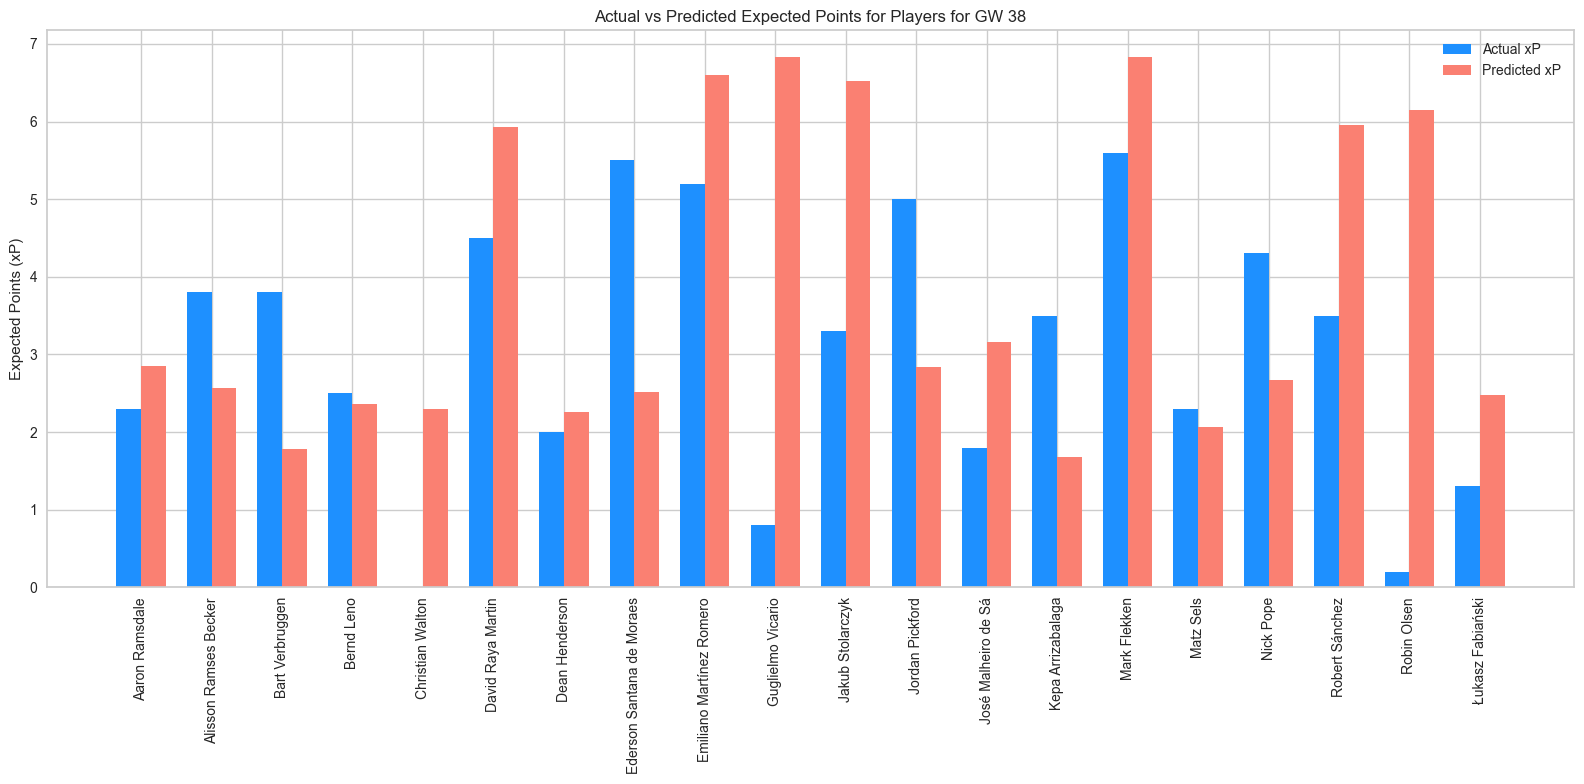

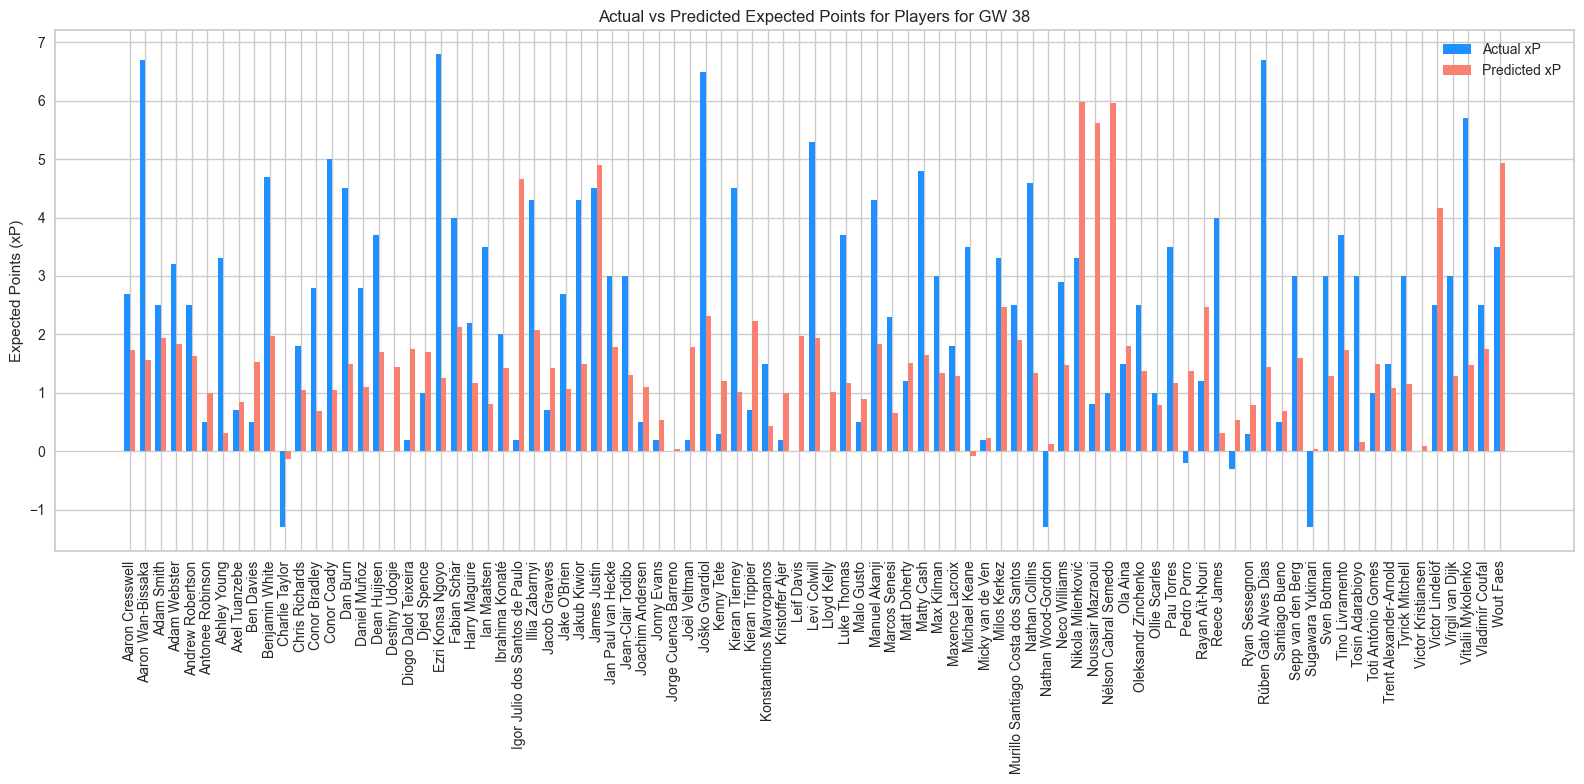

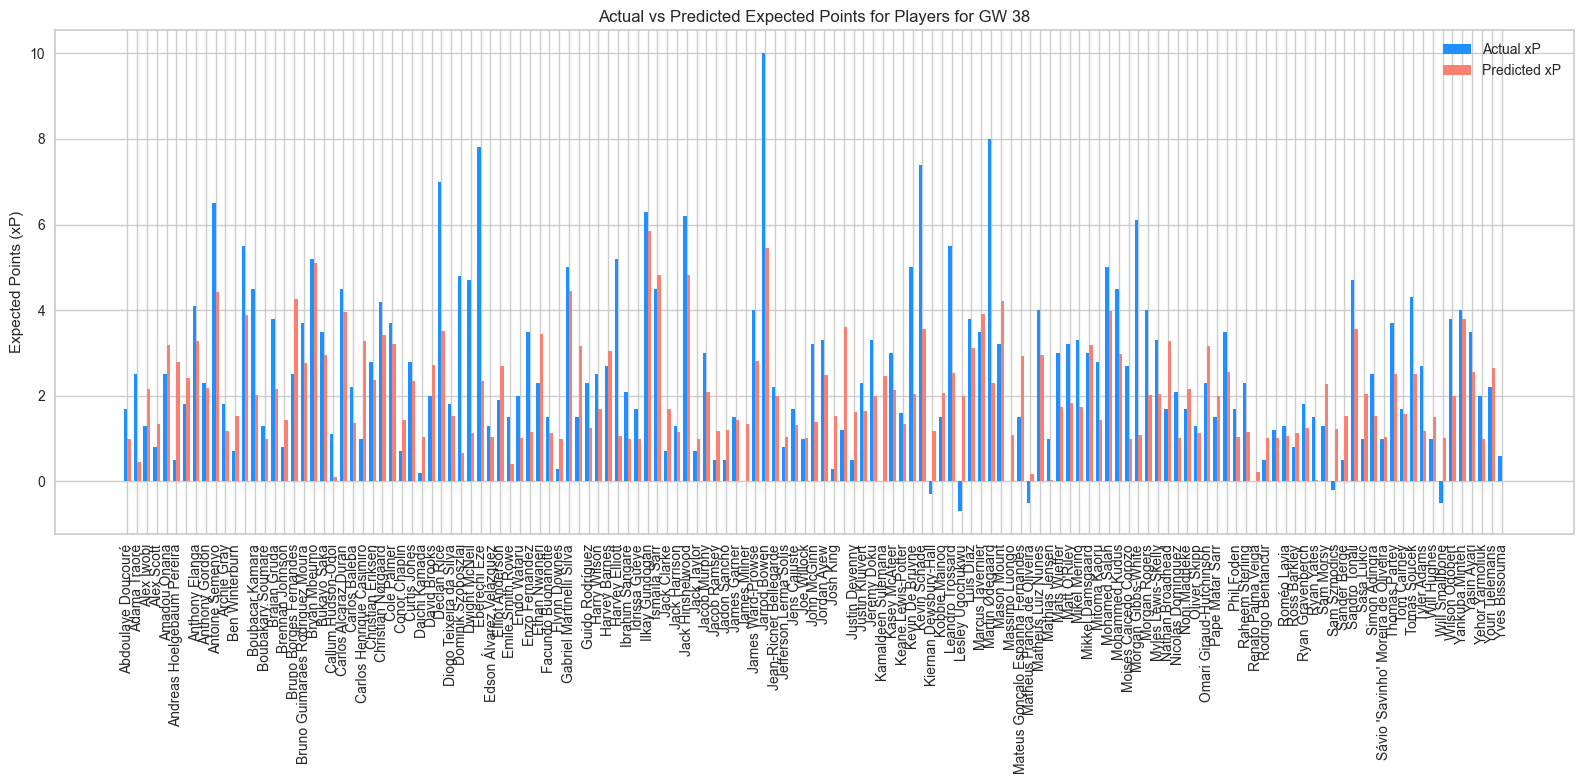

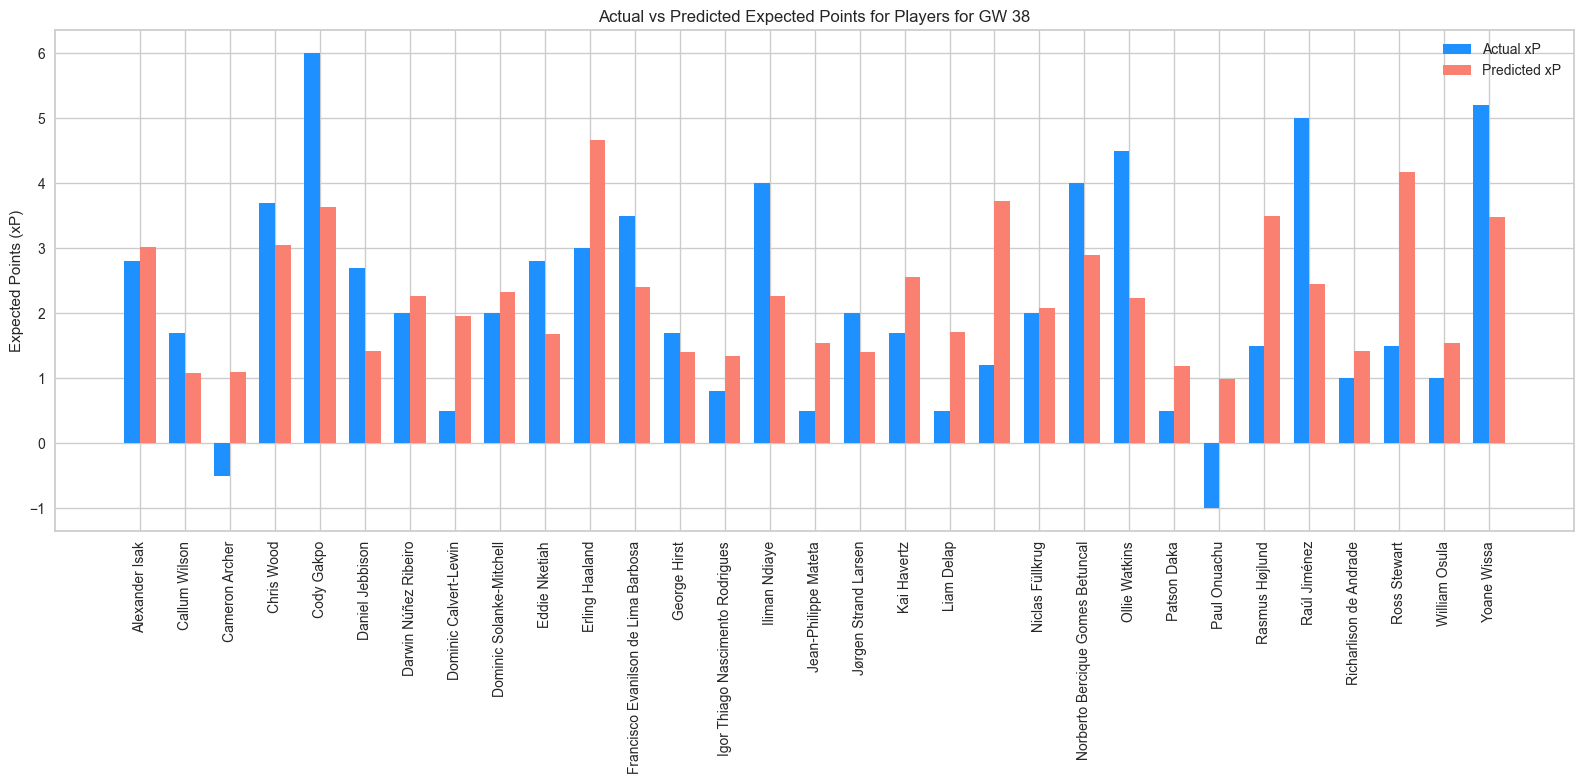

In [80]:
gk_38 = data_38[data_38['position'] == 'GK']
def_38 = data_38[data_38['position'] == 'DEF']
mid_38 = data_38[data_38['position'] == 'MID']
fwd_38 = data_38[data_38['position'] == 'FWD']


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(gk_38['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, gk_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, gk_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 38')
plt.xticks(x, gk_38['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(def_38['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, def_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, def_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 38')
plt.xticks(x, def_38['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(mid_38['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, mid_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, mid_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 38')
plt.xticks(x, mid_38['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()


# Set the width of the bars and the positions for the groups
width = 0.35
x = np.arange(len(fwd_38['fpl_name'])) # The label locations

# Create the figure and axes
plt.figure(figsize=(16, 8))

# Plot the bars for actual xP
plt.bar(x - width/2, fwd_38['xP'], width, label='Actual xP', color='dodgerblue')

# Plot the bars for predicted xP_preds
plt.bar(x + width/2, fwd_38['xP_preds'], width, label='Predicted xP', color='salmon')


plt.ylabel('Expected Points (xP)')
plt.title('Actual vs Predicted Expected Points for Players for GW 38')
plt.xticks(x, fwd_38['fpl_name'], rotation=90) # Label the x-axis with player names, rotated for better fit
plt.legend()

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()